# Feature Attribution using Ranking - v1.4

In [ ]:
import sys

!{sys.executable} -m pip install xgboost
!{sys.executable} -m pip install catboost
!{sys.executable} -m pip install nbimporter
!{sys.executable} -m pip install tensorflow

In [2]:
import time
import numpy as np
import pandas as pd
import zipfile as zf
import nbimporter

import sklearn.ensemble
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb
from catboost import CatBoostClassifier

from scipy.sparse.linalg import eigs

import networkx as nx
import GraphPR as gpr
import PageRank as pr

# Data preprocessing methods

In [3]:
# return one df without nan's on num_cols
# numerical features: fill nan's with median/mean/mode/zeros

def pre_proc_fillna_num_fts(df,num_cols,num_type='mean'):
    df_train= df.copy()

    if(num_type=='median'):
        for col in num_cols:
            ft_median= df_train[col].median()
            df_train[col]= df_train[col].fillna(ft_median)
    elif(num_type=='mode'):
        for col in num_cols:
            ft_mode= df_train[col].value_counts().index[0]
            df_train[col]= df_train[col].fillna(ft_mode)
    elif(num_type=='zeros'):
        for col in num_cols:
            ft_zero= 0
            df_train[col]= df_train[col].fillna(ft_zero)
    else:
        for col in num_cols:
            ft_mean= df_train[col].mean()
            df_train[col]= df_train[col].fillna(ft_mean)

    return df_train

In [4]:
# return one df without nan's on cat_cols
# categorical features: fill nan's with mode/mean/median/zeros

def pre_proc_fillna_cat_fts(df,cat_cols,cat_type='mode'):
    df_train= df.copy()
    
    if(cat_type!='mode' and type(df_train[cat_cols[0]].value_counts().index[0])!=type('str')):
        if(cat_type=='mean'):
            for col in cat_cols:
                ft_mean= df_train[col].mean()
                df_train[col]= df_train[col].fillna(ft_mean)
        elif(cat_type=='median'):
            for col in cat_cols:
                ft_median= df_train[col].median()
                df_train[col]= df_train[col].fillna(ft_median)
        elif(cat_type=='zeros'):
            for col in num_cols:
                ft_zero= 0
                df_train[col]= df_train[col].fillna(ft_zero)
    else:
        for col in cat_cols:
            ft_mode= df_train[col].value_counts().index[0]
            df_train[col]= df_train[col].fillna(ft_mode)

    return df_train

In [5]:
# selected_cols refers only to df's columns with numerical values
# if selected_cols is not defined as argument, all df columns will be normalized

def normalize_selected(df, selected_cols=[]):
    result= df.copy()
    
    if (len(selected_cols)== 0):
        selected_cols= df.columns
    
    for col in selected_cols:
        max_value= df[col].max()
        min_value= df[col].min()
        result[col]= (df[col]- min_value)/ (max_value - min_value)
        
    return result

In [6]:
# return a sorted DataFrame with Features and Importances - OHE compacted, that is, dataset's original features

def ft_importance_df(importances, ft_names, replace_list):
    fti= pd.Series(importances, index=ft_names).sort_values(ascending=False).to_frame().reset_index()
    fti= fti.rename(columns= {'index':'Feature',0:'Importance'}, inplace=False)
    fti['Feature'].replace(replace_list, inplace=True)
    fti= fti.groupby(['Feature']).sum().sort_values('Importance', ascending=False).reset_index()
    
    return fti

# Feature Attribution using Ranking - methods

In [7]:
# return a DataFrame with replaced values (mean/median/mode/zeros/none to categorical and numeric) 
# to fill train cols. df is post-processed (cat_cols encoded)

def replace_values(df,num_cols,num_type='mean',cat_type='none'):
    cat_values= None
    num_values= None
    
    if (cat_type=='mean'):
        cat_values= df.mean(axis=0).to_frame().T
    elif (cat_type=='median'):
        cat_values= df.median(axis=0).to_frame().T
    elif (cat_type=='mode'):
        cat_values= df.mode(axis=0)
    elif (cat_type=='zeros'):
        cat_values= df.loc[0:0,:].copy()
        cat_values.loc[:,:]= 0
    
    if (num_type=='mode'):
        num_values= df.mode(axis=0)
    elif (num_type=='median'):
        num_values= df.median(axis=0).to_frame().T
    elif (num_type=='mean'):
        num_values= df.mean(axis=0).to_frame().T
    elif (num_type=='zeros'):
        num_values= df.loc[0:0,:].copy()
        num_values.loc[:,:]= 0

    if(cat_type!='none'):
        cat_values[num_cols]= num_values[num_cols]
        return cat_values
    
    return num_values

In [8]:
# train the ML model and return its mean accuracy after n_train runs

def train_model_get_acc_mean(model, x_trn, x_tst, y_trn, y_tst, n_train):
    trainings= []
    
    np_ar= np.ndarray((0,0))    # model.fit() expect a 1d array instead of a pd.DataFrame
    pd_df= pd.DataFrame(np_ar)  # we need to verify and change it using values.ravel()
    
    if (type(y_trn)== type(pd_df)):
        
        for i in range(n_train):

            model.fit(x_trn, y_trn.values.ravel())
            acc= sklearn.metrics.accuracy_score(y_tst, model.predict(x_tst))

            trainings.append(acc)
    else:
        for i in range(n_train):

            model.fit(x_trn, y_trn)
            acc= sklearn.metrics.accuracy_score(y_tst, model.predict(x_tst))

            trainings.append(acc)
            
    return np.mean(trainings)

In [9]:
# re-training is needed because machine learning models typically assume that the train and the test data 
# comes from a similar distribution (Hooker et al., 2018)

# model is a NO trained model

# here we return p(x|i) and p(x|ij)
def remove_and_retrain(model, replace_ft_vals, x_trn, x_tst, y_trn, y_tst, n_train, verbose:bool=False):
    acc_no_i= []
    acc_no_ij= []

    n_fts= len(x_trn.columns)

    start= time.time()

    for i in range(n_fts):
        acc_row= []

        # replace the i-th ft with its respective mode/mean to "remove" it. train the ML model and get the 
        # mean accuracy
        train_copy_no_i= x_trn.copy()
        train_copy_no_i.loc[:,train_copy_no_i.columns[i]]= replace_ft_vals.iloc[0,i]

        acc_no_i.append(train_model_get_acc_mean(model, train_copy_no_i, x_tst, y_trn, y_tst, n_train))

        for j in range(n_fts):

            if (i<= j):
                # replace the j-th ft with its respective mode/mean to "remove" it. here, we "remove" the i-th 
                # and the j-th ft
                # train the ML model and get the mean accuracy
                train_copy_no_ij= train_copy_no_i.copy()
                train_copy_no_ij.loc[:,train_copy_no_ij.columns[j]]= replace_ft_vals.iloc[0,j]

                acc_row.append(train_model_get_acc_mean(model, train_copy_no_ij, x_tst, y_trn, y_tst, n_train))
            elif (i> j):
                acc_row.append(acc_no_ij[j][i])

        acc_no_ij.append(acc_row)

    end= time.time()
    
    if (verbose==True):
        print("--- %s seconds ---" % np.round((end- start), 2))

    return acc_no_i, acc_no_ij

In [10]:
# remove WITH NO retraining - to speedup and stability improvements
# model is a TRAINED model

# here we return p(x|i) and p(x|ij)
def remove_and_return_costs(model, replace_ft_vals, x_tst, y_tst, verbose:bool=False):
    acc_no_i= []
    acc_no_ij= []

    n_fts= len(x_tst.columns)

    start= time.time()
    
    np_ar= np.ndarray((0,0))    # model.fit() expect a 1d array instead of a pd.DataFrame
    pd_df= pd.DataFrame(np_ar)  # we need to verify and change it using values.ravel()
    

    for i in range(n_fts):  # remove and predict process to get gains/losses
        acc_row= []

        # replace the i-th ft of test set with its respective mode/mean to "remove" it. 
        x_tst_copy_no_i= x_tst.copy()
        x_tst_copy_no_i.loc[:,x_tst_copy_no_i.columns[i]]= replace_ft_vals.iloc[0,i]

        acc_no_i.append(sklearn.metrics.accuracy_score(y_tst, model.predict(x_tst_copy_no_i)))

        for j in range(n_fts):

            if (i<= j):
                # replace the j-th ft of test with its respective mode/mean to "remove" it. 
                # here, we "remove" the i-th and the j-th ft
                # test the ML model and get the mean accuracy
                x_tst_copy_no_ij= x_tst_copy_no_i.copy()
                x_tst_copy_no_ij.loc[:,x_tst_copy_no_ij.columns[j]]= replace_ft_vals.iloc[0,j]

                acc_row.append(sklearn.metrics.accuracy_score(y_tst, model.predict(x_tst_copy_no_ij)))
            elif (i> j):
                acc_row.append(acc_no_ij[j][i])

        acc_no_ij.append(acc_row)

    end= time.time()
    
    if (verbose==True):
        print("--- %s seconds ---" % np.round((end- start), 2))

    return acc_no_i, acc_no_ij

In [11]:
import math
from sklearn.neighbors import NearestNeighbors

# find the test_size nearest neighbors from a target_x instance
# return train, test, labels_train, labels_test datsets based on knn
# target_x and target_y are into testX and testY

def knn_train_test_split(df_x, df_y, target_x, target_y, test_size= 0.2):
    
    m_ins= df_x.shape[0] # m x n dataset

    neighbors= math.floor(test_size* m_ins)

    knn= NearestNeighbors(n_neighbors= neighbors)
    knn.fit(df_x)

    knn_index= knn.kneighbors(target_x, return_distance=False)
    
    trainX= df_x.drop(df_x.index[knn_index[0]])
    trainY= df_y.drop(df_y.index[knn_index[0]])

    testX= df_x.loc[df_x.index[knn_index[0]]]
    testY= df_y.loc[df_y.index[knn_index[0]]]

    testX= pd.concat([target_x, testX])
    testY= pd.concat([target_y, testY])
    
    return trainX, testX, trainY, testY

In [12]:
# find the neighb_size nearest neighbors from a target_x instance
# return data and target datsets based on knn
# with target_x and target_y into x_fts and y_trg

def knn_neighborhood(df_x, df_y, target_x, target_y, neighb_size= 0.2, target_in:bool=True):
    
    m_ins= df_x.shape[0] # m x n dataset

    neighbors= math.floor(neighb_size* m_ins)

    knn= NearestNeighbors(n_neighbors= neighbors)
    knn.fit(df_x)

    knn_index= knn.kneighbors(target_x, return_distance=False)

    x_fts= df_x.loc[df_x.index[knn_index[0]]]
    y_trg= df_y.loc[df_y.index[knn_index[0]]]

    if (target_in== True):
        x_fts= pd.concat([target_x, x_fts])
        y_trg= pd.concat([target_y, y_trg])
    
    return x_fts, y_trg

In [13]:
# df_x and df_y doesn't contain target_x and target_y
# model is a a TRAINED model

# here we return p(x|i) and p(x|ij)
def knn_remove_and_return_costs(model, replace_ft_vals, x_tst, y_tst, target_x, target_y, 
                                neighb_size=0.01, verbose:bool=False):
    
    start= time.time()

    m_ins= x_tst.shape[0] # m x n dataset
    n_fts= x_tst.shape[1]
    
    k_viz= math.floor(neighb_size* m_ins)
    k_viz_aux= math.floor(np.sqrt(m_ins))
    
    if (k_viz< k_viz_aux):
        k_viz= k_viz_aux
        
    # here, we generate a neighborhood of the target instance
    x_neighb, y_neighb= knn_neighborhood(x_tst, y_tst, target_x, target_y, neighb_size= (k_viz/ m_ins))    

    acc_no_i, acc_no_ij= remove_and_return_costs(model, replace_ft_vals, x_neighb, y_neighb)
    
    end= time.time()
    
    if (verbose==True):
        print("--- %s seconds ---" % np.round((end- start), 2))
    
    return acc_no_i, acc_no_ij

In [14]:
from sklearn.model_selection import KFold, StratifiedKFold

# df_x and df_y doesn't contain target_x and target_y
# model is a a TRAINED model

# here we return p(x|i) and p(x|ij)
def knnfold_remove_and_return_costs(model, replace_ft_vals, x_tst, y_tst, target_x, target_y, 
                                neighb_size=0.01, k_folds=5, verbose:bool=False):
    
    start= time.time()

    m_ins= x_tst.shape[0] # m x n dataset
    n_fts= x_tst.shape[1]
    
    k_viz= math.floor(neighb_size* m_ins)
    k_viz_aux= math.floor(np.sqrt(m_ins))
    
    if (k_viz< k_viz_aux):
        k_viz= k_viz_aux
        
    # here, we generate a neighborhood of the target instance
    x_neighb, y_neighb= knn_neighborhood(x_tst, y_tst, target_x, target_y, 
                                         neighb_size= (k_viz/ m_ins), target_in= False) 
    

    K_folds= math.floor(np.sqrt(n_fts))

    if (K_folds< 5):
        K_folds= 5
        
    if (K_folds< k_folds):
        K_folds= k_folds   

    skf= StratifiedKFold(n_splits= K_folds, random_state=1234, shuffle=True)    
        
    acc_no_i= np.zeros(n_fts)
    acc_no_ij= np.zeros((n_fts,n_fts))
    
    for train_index, test_index in skf.split(x_neighb, y_neighb):
    
        x_fold= x_neighb.iloc[train_index]
        y_fold= y_neighb.iloc[train_index]
        
        # add the target instance on the fold set
        x_fold.append(target_x)
        y_fold.append(target_y)
    
        aux_acc_no_i, aux_acc_no_ij= remove_and_return_costs(model, replace_ft_vals, x_fold, y_fold)
    
        acc_no_i += aux_acc_no_i
        acc_no_ij += aux_acc_no_ij

    
    acc_no_i /= K_folds
    acc_no_ij /= K_folds
    
    end= time.time()
    
    if (verbose==True):
        print("--- %s seconds ---" % np.round((end- start), 2))
    
    return acc_no_i, acc_no_ij

# Costs matrix methods - old

In [15]:
# here we return | p(x|ij) - p(x|j) |

def get_p_matrix_v2(n_fts, no_j, no_ij):
    p_matrix= np.zeros((n_fts, n_fts))

    for i in range(n_fts):
        for j in range(n_fts):
            
            pj= no_j[j]
            pij= no_ij[i][j]

            p_matrix[i][j]= np.abs(pij- pj)
                
    return p_matrix

In [16]:
# here we return (| p(x|ij) - p(x|j) | + | p(x|i) - p(x) |) / 2

def get_p_matrix_v3(n_fts, all_fts, no_i, no_j, no_ij):
    p_matrix= np.zeros((n_fts, n_fts))
    p= all_fts

    for i in range(n_fts):
        pi= no_i[i]
        
        for j in range(n_fts):
            
            pj= no_j[j]
            pij= no_ij[i][j]

            p_matrix[i][j]= (np.abs(pij- pj)+ np.abs(pi- p))/ 2
                
    return p_matrix

In [17]:
# here we return (| p(x|ij) - p(x|i) | + | p(x|j) - p(x) |) / 2

def get_p_matrix_v4(n_fts, all_fts, no_i, no_j, no_ij):
    p_matrix= np.zeros((n_fts, n_fts))
    p= all_fts

    for i in range(n_fts):
        pi= no_i[i]
        
        for j in range(n_fts):
            
            pj= no_j[j]
            pij= no_ij[i][j]

            p_matrix[i][j]= (np.abs(pij- pi)+ np.abs(pj- p))/ 2
                
    return p_matrix

# Stationary distribution methods

In [18]:
# the stationary distribution is the fraction of time that the system spends in each state as the 
# number of samples approaches infinity
# it looks like there's not a built-in method to find the stationary distribution

# converts a matrix to a row stochastic matrix - a real square matrix, with each row summing to 1
def to_row_stochastic_matrix(M):
    result= (np.asarray(M)).copy()
    
    for row in result:
        n= sum(row)
        if (n> 0):
            row[:]= [f/sum(row) for f in row]
    
    return result

In [19]:
# a stochastic matrix is a square matrix used to describe the transitions of a Markov chain 
# each of its entries is a nonnegative real number representing a probability
# a right (row) stochastic matrix is a real square matrix, with each row summing to 1

# if M is a row stochastic matrix, return TRUE

def check_row_stochastic_matrix(M):
    dim= M.shape
    
    if (dim[0]!= dim[1]):
        return False
    
    for row in M:
        n= sum(row)
        if (n< 0.99):
            return False
        
    return True

In [20]:
# if M is a singular matrix, return TRUE

def singular_matrix(M):
    
    if not (np.linalg.cond(M) < 1/sys.float_info.epsilon):
        return True
            
    return False

In [21]:
# the stationary distribution - analytical solution
# return 1D array

def stationary_dist_v1(stochastic_matrix):
    
    stationary= np.zeros(stochastic_matrix.shape[1])
    
    #if (check_row_stochastic_matrix(stochastic_matrix)==False):
    #    return stationary
    
    size_A= stochastic_matrix.shape[1]
    ones= [1]* size_A

    A= np.append(np.transpose(stochastic_matrix)- np.identity(size_A),[ones],axis=0)

    v= np.zeros(size_A+ 1)
    v[size_A]= 1
    v= np.transpose(v)
    
    At_dA= np.transpose(A).dot(A)
    At_dv= np.transpose(A).dot(v)
    
    if (singular_matrix(At_dA)==True):
        try:
            # returns x, residuals, rank, s
            # x is the least-squares solution, residuals the sum, rank the matrix rank of input A, 
            # and s the singular values of A.
            stationary= np.linalg.lstsq(At_dA, At_dv, rcond=None)[0]
        except:
            pass
    else:
        try:
            stationary= np.linalg.solve(At_dA, At_dv)
        except:
            pass

    return np.abs(stationary)

In [22]:
# the stationary distribution - another analytical solution
# return 1D array

def stationary_dist_v2(stochastic_matrix):
    
    stationary= np.zeros(stochastic_matrix.shape[1])
    
    #if (check_row_stochastic_matrix(stochastic_matrix)==False):
    #    return stationary
    
    # we have to transpose so that Markov transitions correspond to right multiplying by a column vector
    eigval, eigvec= eigs(stochastic_matrix.T, k=1, which='LM')
    stationary= eigvec/ eigvec.sum()

    # eigs finds complex eigenvalues and eigenvectors, so you'll want the real part
    stationary= stationary.real

    # at the end we have to transpose the stationary vector to get a 1D array    
    return np.abs(stationary.T[0])

In [23]:
# convert a p_matrix to a right stochastic matrix - a real square matrix, with each row summing to 1

def p_matrix_to_row_stochastic_matrix(p_matrix):
    
    st_matrix= np.asarray(p_matrix)
    
    # now convert to right stochastic matrix
    st_matrix= to_row_stochastic_matrix(st_matrix)
    
    if (check_row_stochastic_matrix(st_matrix)==False):
        return np.zeros(st_matrix.shape)
    
    return st_matrix

In [24]:
# find the stationary distribution
# return 1D array (version=1) or 2D array (version=1)

def p_matrix_to_stationary_dist(p_matrix, version=1):
    
    st_matrix= np.asarray(p_matrix)
    
    # now convert to right stochastic matrix
    st_matrix= to_row_stochastic_matrix(st_matrix)
    
    # then get the stationary distribution
    stationary_d= []
    
    if (version==1):
        stationary_d= stationary_dist_v1(st_matrix)
    else:
        stationary_d= stationary_dist_v2(st_matrix)
    
    return stationary_d

# New codes - Feature Attribution using Ranking

In [517]:
# remove WITH NO retraining - add WITH NO retraining - to speedup and stability improvements
# model is a TRAINED classifier model

# NEW VERSION based on class predicted probabilities

# fx_prob is the model probability output from the instance under explanation
# fx_pred is the model predicted class output from the instance under explanation

# RETURN pairs of costs p(x|i) and p(x|ij), one pair from remove and one pair from add features
# order of return - no_i, no_ij, with_i, with_ij

def far_gen_costs(model, n_fts, replace_ft_vals, x_to_exp, y_true, fx_prob, fx_pred, use_preds:bool=True, 
                  verbose:bool=False):
    acc_no_i= []
    acc_no_ij= []
    
    acc_with_i= []
    acc_with_ij= []

    start= time.time()

    for i in range(n_fts):  # remove/add and predict process to get the gains/losses
        acc_row_n= []
        acc_row_w= []

        # replace_ft_vals contains "neutral" values to each feature
        # replace the i-th ft of x_to_exp with its respective "neutral" value to "REMOVE" this ft
        x_to_exp_no_i= x_to_exp.copy()
        x_to_exp_no_i.loc[:,x_to_exp_no_i.columns[i]]= replace_ft_vals.iloc[0,i]
        
        # ADD the i-th value from x_to_exp into a "neutral" instance one by one to assess the gain/loses
        x_to_exp_with_i= replace_ft_vals.copy()
        x_to_exp_with_i.loc[:,x_to_exp_with_i.columns[i]]= x_to_exp.iloc[0,i]
        

        # REMOVING - remove an important ft tends to yield a gain/cost in model performance
        #            remove a non-important ft tends to yield no or just a little gain/cost in performance
        # ADDING - add an important ft to the "neutral" instance tends to yield a gain/cost in performance
        #          add a non-important ft to "neutral" tends to yield no or little gain/cost in performance
        # if True, predicted class from fx_pred is used. If false, true label from y_true is used
        if (use_preds== True):
            acc_no_i.append(fx_prob - get_avg_pred_proba(model, x_to_exp_no_i, fx_pred))
            acc_with_i.append(get_avg_pred_proba(model, x_to_exp_with_i, fx_pred) - fx_prob)
        else:
            acc_no_i.append(fx_prob - get_avg_pred_proba(model, x_to_exp_no_i, 
                                                         y_true.values.ravel().astype(int)))
            acc_with_i.append(get_avg_pred_proba(model, x_to_exp_with_i, 
                                                 y_true.values.ravel().astype(int)) - fx_prob)
        
        
        for j in range(n_fts):

            if (i<= j):
                # replace the j-th ft of x_to_exp with its respective "neutral" value to "REMOVE" this ft
                # here we "remove" the j-th ft considering we have already removed the i-th ft before
                x_to_exp_no_ij= x_to_exp_no_i.copy()
                x_to_exp_no_ij.loc[:,x_to_exp_no_ij.columns[j]]= replace_ft_vals.iloc[0,j]
                
                # x_to_exp_with_i contains "neutral" values to each ft except in i-th position
                # then we add the j-th value from x_to_exp one by one the assess the gain/loses
                x_to_exp_with_ij= x_to_exp_with_i.copy()
                x_to_exp_with_ij.loc[:,x_to_exp_with_ij.columns[j]]= x_to_exp.iloc[0,j]
                
                
                # if True, predicted class from fx_pred is used. If false, true label from y_true is used
                if (use_preds== True):
                    acc_row_n.append(fx_prob - get_avg_pred_proba(model, x_to_exp_no_ij, fx_pred))
                    acc_row_w.append(get_avg_pred_proba(model, x_to_exp_with_ij, fx_pred) - fx_prob)
                else:
                    acc_row_n.append(fx_prob - get_avg_pred_proba(model, x_to_exp_no_ij, 
                                                                  y_true.values.ravel().astype(int)))
                    acc_row_w.append(get_avg_pred_proba(model, x_to_exp_with_ij, 
                                                        y_true.values.ravel().astype(int)) - fx_prob)
                    
            elif (i> j):
                acc_row_n.append(acc_no_ij[j][i])
                acc_row_w.append(acc_with_ij[j][i])

        acc_no_ij.append(acc_row_n)
        acc_with_ij.append(acc_row_w)
        

    end= time.time()
    
    if (verbose==True):
        print("--- %s seconds ---" % np.round((end- start), 2))

    return acc_no_i, acc_no_ij, acc_with_i, acc_with_ij

In [518]:
# remove WITH NO retraining - add WITH NO retraining - to speedup and stability improvements
# model is a TRAINED regressor model

# return pairs of costs p(x|i) and p(x|ij), one pair from remove and one pair from add features
# order of return - no_i, no_ij, with_i, with_ij

def far_gen_costs_reg(model, n_fts, replace_ft_vals, x_to_exp, verbose:bool=False):
    acc_no_i= []
    acc_no_ij= []
    
    acc_with_i= []
    acc_with_ij= []

    start= time.time()

    for i in range(n_fts):  # remove/add and predict process to get the gains/losses
        acc_row_n= []
        acc_row_w= []

        # replace_ft_vals contains "neutral" values to each feature
        # replace the i-th ft of x_to_exp with its respective "neutral" value to "REMOVE" this ft
        x_to_exp_no_i= x_to_exp.copy()
        x_to_exp_no_i.loc[:,x_to_exp_no_i.columns[i]]= replace_ft_vals.iloc[0,i]
        
        # ADD the i-th value from x_to_exp one by one the assess the gain/loses
        x_to_exp_with_i= replace_ft_vals.copy()
        x_to_exp_with_i.loc[:,x_to_exp_with_i.columns[i]]= x_to_exp.iloc[0,i]
        
        acc_no_i.append(model.predict(x_to_exp_no_i)[0])
        acc_with_i.append(model.predict(x_to_exp_with_i)[0])
        
        for j in range(n_fts):
            
            if (i<= j):
                # replace the j-th ft of x_to_exp with its respective "neutral" value to "REMOVE" this ft
                # here we "remove" the j-th ft considering we have already removed the i-th ft before
                x_to_exp_no_ij= x_to_exp_no_i.copy()
                x_to_exp_no_ij.loc[:,x_to_exp_no_ij.columns[j]]= replace_ft_vals.iloc[0,j]
                
                # x_to_exp_with_i contains "neutral" values to each ft except in i-th position
                # then we add the j-th value from x_to_exp one by one the assess the gain/loses
                x_to_exp_with_ij= x_to_exp_with_i.copy()
                x_to_exp_with_ij.loc[:,x_to_exp_with_ij.columns[j]]= x_to_exp.iloc[0,j]
                
                acc_row_n.append(model.predict(x_to_exp_no_ij)[0])
                acc_row_w.append(model.predict(x_to_exp_with_ij)[0])
                
            elif (i> j):
                acc_row_n.append(acc_no_ij[j][i])
                acc_row_w.append(acc_with_ij[j][i])

        acc_no_ij.append(acc_row_n)
        acc_with_ij.append(acc_row_w)
        
    end= time.time()
    
    if (verbose==True):
        print("--- %s seconds ---" % np.round((end- start), 2))

    return acc_no_i, acc_no_ij, acc_with_i, acc_with_ij

In [519]:
# here we return our simplified shapley value for one variable regarding first row of Shapley powerset

def get_phi_i(n_fts, fi, f0): 
    
    phi_i= (1/ n_fts) * (fi- f0)
    
    return phi_i

In [520]:
def get_vector_phi_i(n_fts, full_ft, no_i):
    p_vector= np.zeros((n_fts))
    f0= full_ft
    
    for i in range(n_fts):
        fi= no_i[i]
        
        p_vector[i]= get_phi_i(n_fts, fi, f0)
        
    return p_vector

In [521]:
# here we return our simplified shapley value for two variables regarding second row of Shapley powerset

def get_phi_ij(n_fts, fij, fi, fj, f0):
    
    first_term= (1/ n_fts) * (fi- f0)
    scond_term= (1/ (n_fts * (n_fts- 1))) * (2*fij- fi- fj)
    
    phi_ij= first_term+ scond_term
    
    return phi_ij

In [522]:
def get_matrix_phi_ij(n_fts, full_ft, no_i, no_ij):
    phi_matrix= np.zeros((n_fts, n_fts))
    f0= full_ft

    for i in range(n_fts):
        fi= no_i[i]
        
        for j in range(n_fts):
            fj= no_i[j]
            
            if (i!= j):
                # there is no phi_ii in Shapley values
                fij= no_ij[i][j]
                
                phi_matrix[i][j]= get_phi_ij(n_fts, fij, fi, fj, f0)
        
    return phi_matrix    

In [523]:
# here we return shapley values for phi_ij charged to phi_i and phi_j

def get_sh_p_matrix(n_fts, phi_i, phi_ij, mag:bool=False, zeroDiag:bool=True):
    p_matrix= np.zeros((n_fts, n_fts))

    for i in range(n_fts):
        pi= phi_i[i]
        
        for j in range(n_fts):
            pij= phi_ij[i][j]

            # note that phi_ij computation include phi_i effect
            # then we subtract phi_i from phi_ij to get p_ij

            if (i!= j):
                if (mag==True):
                    p_matrix[i][j]= np.abs(pij- pi)
                else:
                    p_matrix[i][j]= (pij- pi)
            elif (i==j and zeroDiag==False):
                if (mag==True):
                    p_matrix[i][j]= np.abs(pi)
                else:
                    p_matrix[i][j]= pi
                
    return p_matrix

In [524]:
# The permutation feature importance algorithm based on Fisher, Rudin, and Dominici (2018):
# 
# Input: Trained model f, feature matrix X, target vector y, error measure L(y, f)
# 
# 1. Estimate the original model error e_org = L(y, f(X)) (e.g. mean squared error)
# 2. For each feature j in {1,...,p} do:
#    Generate feature matrix X_per by permuting feature j in the data X. 
#    This breaks the association between feature j and true outcome y.
#    Estimate error e_per = L(Y, f(X_per)) based on the predictions of the permuted data.
# Calculate permutation feature importance as quotient FIj = e_per / e_org or difference FIj = e_per - e_org
# Sort features by descending FI.

In [525]:
# REMOVING - remove an important ft tends to yield a gain/cost in model performance
#            remove a non-important ft tends to yield no or just a little gain/cost in performance
# ADDING - add an important ft to the "neutral" instance tends to yield a gain/cost in performance
#          add a non-important ft to "neutral" tends to yield no or little gain/cost in performance

In [526]:
# here we return p(x|ij) - p(x|i)

def get_p_matrix_dif(n_fts, no_i, no_ij, remove:bool=True, zeroDiag:bool=True):
    p_matrix= np.zeros((n_fts, n_fts))

    for i in range(n_fts):
        pi= no_i[i]
        
        for j in range(n_fts):
            
            pij= no_ij[i][j]

            if (remove==True):
                p_matrix[i][j]= pi- pij # when removing two important variables, we may have a more 
            else:                       # significant decrease in performance
                p_matrix[i][j]= pij- pi # similar, when adding two important variables, we may have a more
                                        # significant increase in performance
            if (zeroDiag==False and i==j):
                p_matrix[i][j]= pi
                
    return p_matrix

In [527]:
# here we return | p(x|ij) - p(x|i) |

def get_p_matrix_mag(n_fts, no_i, no_ij, remove:bool=True, zeroDiag:bool=True):
    p_matrix= np.zeros((n_fts, n_fts))

    for i in range(n_fts):
        pi= no_i[i]
        
        for j in range(n_fts):
            
            pij= no_ij[i][j]

            if (remove==True):
                p_matrix[i][j]= np.abs(pi- pij)
            else:
                p_matrix[i][j]= np.abs(pij- pi)
            
            if (zeroDiag==False and i==j):
                p_matrix[i][j]= np.abs(pi)
                
    return p_matrix

In [528]:
# here we return (p(x|ij) - p(x|i))^2

def get_p_matrix_div(n_fts, no_i, no_ij, remove:bool=True, zeroDiag:bool=True):
    p_matrix= np.zeros((n_fts, n_fts))

    for i in range(n_fts):
        pi= no_i[i]
        
        for j in range(n_fts):
            
            pij= no_ij[i][j]

            if (remove==True):
                p_matrix[i][j]= np.power((pi- pij), 2)
            else:
                p_matrix[i][j]= np.power((pij- pi), 2)
            
            if (zeroDiag==False and i==j):
                p_matrix[i][j]= np.power((pi), 2)
                
    return p_matrix

In [529]:
from scipy.spatial import distance

# here we return the euclidena distance between p(x|ij) and p(x|i)

def get_p_matrix_dist(n_fts, no_i, no_ij, remove:bool=True, zeroDiag:bool=True):
    p_matrix= np.zeros((n_fts, n_fts))

    for i in range(n_fts):
        pi= np.sum(no_ij[i])
        
        for j in range(n_fts):
            
            pij= no_ij[i][j]

            if (remove==True):
                p_matrix[i][j]= distance.euclidean(pi, pij)
            else:
                p_matrix[i][j]= distance.euclidean(pij, pi)
                
            if (zeroDiag==False and i==j):
                p_matrix[i][j]= pi
                
    return p_matrix

In [530]:
from scipy.special import log_softmax
from scipy.special import softmax
np.set_printoptions(precision=5)

In [531]:
# Compute softmax values for each sets of scores in x
# x: numpy.ndarray, return numpy.ndarray
# x: pandas DataFrame, return pandas DataFrame

def my_softmax(x):
    
    npx= np.asarray(x)
    
    assert len(npx.shape)== 2
    s= np.max(npx, axis= 1)
    s= s[:, np.newaxis]
    e_x= np.exp(npx - s)
    div= np.sum(e_x, axis= 1)
    div= div[:, np.newaxis]
    
    result= e_x/ div
    
    dfx= pd.DataFrame(result)
    if (type(x)== type(dfx)):
        dfx.columns= x.columns
        return dfx
    
    return result

In [532]:
# normalize a numpy.ndarray to 0-1 range
# x: numpy.ndarray, return numpy.ndarray

def normalize(x):
    
    result= (x- np.min(x))/ (np.max(x)- np.min(x))
        
    return result

In [533]:
def translate_neg_vals(x):
    min_x= np.min(x)
    
    if (min_x< 0):
        x_t= x - min_x
        return x_t
    
    return x

In [534]:
def sigmoid(x):
    
    return 1 / (1 + np.exp(-x))

In [535]:
# Return E[X] the Expected Value of a model
# Than E[X] = V(O1)*P(O1) + V(O2)*P(O2) + ... + V(On)*P(On)
# E[X] is a linear combination of all possible outcomes associated with it
# We decompose each outcome, On, to a combination of the probability of that outcome, P(On),
# and its associated value, V(On).

# RETURN the mean predicted probabilities, considering the true classes

def expected_value(model, x_train, y_train):
    
    # Expected value over the train data
    f_x= model.predict(x_train)
    p_x= model.predict_proba(x_train)

    tam= len(f_x)
    pred= 0
    
    for i in range(tam):
        pred= pred+ p_x[i][y_train[i].astype(int)]
        
    avg_pred= pred/ tam
    
    return avg_pred

In [536]:
from sklearn.metrics import confusion_matrix

# Expected value over the train data, considering the true predictions
# RETURN the mean predicted probabilities, considering E[f(X)]= sum{i=1 to n}[f(xi)p(X= xi)]

def expected_value_v2(model, x_train, y_train):
    
    # Expected value over the train data
    f_x= model.predict(x_train)
    p_x= model.predict_proba(x_train)
    
    assert len(y_train)== len(p_x), "Same size parameters expected to x and y"
    
    """
    # Alternative version using a confusion matrix - TODO
    y_pred= f_xi
    
    # y_true, y_pred
    tn, fp, fn, tp= confusion_matrix(x_train, y_pred).ravel()
    
    total= x_trn.shape[0]
    positives= tp + fn
    negatives= tn + fp
    
    p_rate= positives/ total
    n_rate= negatives/ total
    
    tpr= tp/ (tp + fn)
    tnr= tn/ (tn + fp)
    fpr= fp/ (tn + fp)
    fnr= fn/ (tp + fn)
    
    # v() function must to quantify a cost
    expect_value= p_rate* (tpr* v(tpr) + fnr* v(fnr)) + 
                  n_rate* (tnr* v(tnr) + fpr* v(fpr))    
    """
    
    tam= len(f_x)
    pred= 0
    
    for i in range(tam):
        # here only the true predicted instances
        if (f_x[i] == y_train[i]):
            pred= pred+ p_x[i][y_train[i].astype(int)]
        
    avg_pred= pred/ tam
    
    return avg_pred

In [537]:
# Expected value can be understood as the average model output across the training set, and the true labels
# SHAP paper mention a dataset "would be predicted if we did not know any features"

# The 'absence of features' or better 'not knowing the feature' needs to be defined/considered carefully. 
# In the context of SHAP it doesn't meant that Xi=0 but it means that we do not know the value of Xi
# but we still may know the distribution of potential values of Xi or we could estimate this distribution 
# based on the data, in practice, a mean value is considered, and then, we average over this predicted 
# probs to each label.

# Receive one instance x_mean from train dataset mean and y_train, the entire labels_train

# RETURN the mean probability of x_mean belonging to the classes in y_train

def expected_value_x_mean(model, x_mean, y_train):
    
    # Expected value over the mean from train data
    p_x= model.predict_proba(x_mean)

    tam= len(y_train)
    pred= 0
    
    for i in range(tam):
        pred= pred+ p_x[0][y_train[i].astype(int)]
        
    avg_pred= pred/ tam
    
    return avg_pred

In [538]:
# get the mean predicted probabilities, considering the informed class labels

# RETURN the probability of x_data belonging to the class y_data

def get_avg_pred_proba(model, x_data, y_data):
    
    p_x= model.predict_proba(x_data)
        
    assert len(y_data)== len(p_x), "Same size parameters expected to x and y"
    
    tam= len(p_x)
    pred= 0
    
    for i in range(tam):
        pred= pred+ p_x[i][y_data[i]]
        
    avg_pred= pred/ tam

    return avg_pred

In [539]:
# RETURN the mean of predictions from a REGRESSOR model

def reg_expected_value(model, x_train):
    
    # Expected value over the train data
    f_x= model.predict(x_train)

    tam= len(f_x)
    pred= 0
    
    for i in range(tam):
        pred= pred+ f_x[i]
        
    avg_pred= pred/ tam
    
    return avg_pred

In [540]:
# split p_matrix matrix into positive and negative parts
# return the positive and the negative values from p_matrix

def split_pos_neg_p_matrix(p_matrix):
    
    pos_p_matrix= np.clip(p_matrix, 0, float('inf'))
    neg_p_matrix= np.clip(p_matrix, float('-inf'), 0)
            
    return pos_p_matrix, neg_p_matrix

In [541]:
# receive the feature ranking vector sum its abs values and return a regularized version

def ft_ranking_regularization(ft_ranking):
    
    tam_fts= len(ft_ranking)

    fator= np.sum(np.abs(ft_ranking))
        
    if (fator==0):
        fator= 1
        
    #np.seterr(divide='ignore', invalid='ignore')

    ft_ranking_reg= ft_ranking/ fator
        
    if (np.isnan(np.sum(ft_ranking_reg))==True):
        ft_ranking_reg= np.zeros(tam_fts)+(1/tam_fts)
        
    if (np.sum(np.abs(ft_ranking_reg))==0):
        ft_ranking_reg= ft_ranking_reg+(1/tam_fts)
        
    return ft_ranking_reg

In [542]:
# convert probabilities to log odds

def pred_proba_to_log_odds(p):
    
    return np.log(p/(1-p))

In [543]:
# transform FAR information into SHAP explanation data

import shap
shap.initjs()

def to_sh_exp(explain_vals, base_prob, inst_vals, ft_names):

    sh_exp= shap.Explanation(values=explain_vals, base_values=pred_proba_to_log_odds(base_prob), 
                             data=inst_vals, 
                             feature_names= np.asarray(ft_names).tolist())

    return sh_exp

In [544]:
def save_dataset(df, file_name='datasets/FAR_data.csv'):

    lines= df.shape[0]
    colls= df.shape[1]

    f= open(file_name, 'w')

    line= str(df.columns[0])

    for i in range((colls-1)):
        line= line+','+str(df.columns[(i+1)])

    line= line+'\n'
    f.write(line)

    df_array= np.asarray(df)
    line= str(df.columns[0])

    for i in range(lines):
        elements= df_array[i]
        line= str(elements[0])

        for j in range((colls-1)):
            line= line+','+str(elements[(j+1)])

        line= line+'\n'
        f.write(line)

    f.close()

# Tests

In [105]:
import synthetic_data as syn

synth= syn.synthetic_data_generator(n=500,df=True)

In [54]:
#save_dataset(synth, 'datasets/FAR_data.csv')
synth= pd.read_csv('datasets/FAR_data.csv')

# split synth into features (x) and target (y)
x_syn= synth.loc[:,synth.columns[0:4]]
y_syn= synth.loc[:,synth.columns[4:5]]

x_syn.head()

,core_1,core_2,noise_1,noise_2
0,-1.297434,1.480258,-1.047823,-1.235156
1,-2.255077,1.190942,-0.573914,-3.008057
2,-3.336307,3.258936,-0.030324,-0.361786
3,0.672172,1.928683,-0.456206,-3.051892
4,-1.106266,3.345063,-3.481175,-1.105859


In [55]:
print(np.round(synth.memory_usage().sum() / 10**6, 2), "MB")

0.04 MB


In [56]:
soft_x_syn= pd.DataFrame(softmax(np.asarray(x_syn)), columns=x_syn.columns)

soft_x_syn.head()

,core_1,core_2,noise_1,noise_2
0,0.000010,0.000168,0.000013,0.000011
1,0.000004,0.000126,0.000022,0.000002
2,0.000001,0.000995,0.000037,0.000027
3,0.000075,0.000263,0.000024,0.000002
4,0.000013,0.001084,0.000001,0.000013


In [57]:
# Normalization
from sklearn.preprocessing import MinMaxScaler

# All dataset is numeric
#scaler= MinMaxScaler(feature_range=(0, 1))
#norm_x_syn= scaler.fit_transform(np.asarray(x_syn))
#norm_x_syn= pd.DataFrame(norm_x_syn, columns=x_syn.columns)

norm_x_syn= normalize_selected(x_syn)

norm_x_syn.head()

,core_1,core_2,noise_1,noise_2
0,0.425977,0.626863,0.368465,0.345838
1,0.359321,0.603430,0.427822,0.123927
2,0.284062,0.770929,0.495906,0.455156
3,0.563072,0.663184,0.442565,0.118440
4,0.439284,0.777905,0.063690,0.362022


In [58]:
# Standarization
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler().fit(np.asarray(x_syn))
# realiza a padronização (média= 0, variância= 1)
stand_x_syn= scaler.transform(np.asarray(x_syn))
stand_x_syn= pd.DataFrame(stand_x_syn, columns=x_syn.columns)

stand_x_syn.head()

,core_1,core_2,noise_1,noise_2
0,-0.103626,0.267269,-0.428075,-0.498028
1,-0.577271,0.116797,-0.225488,-1.265198
2,-1.112041,1.192347,0.006886,-0.120102
3,0.870530,0.500491,-0.175170,-1.284166
4,-0.009076,1.237141,-1.468284,-0.442078


In [59]:
from scipy.stats.contingency import margins

x_mg, y_mg= margins(np.asarray(norm_x_syn))

y_mg/ norm_x_syn.shape[0]

array([[0.44056, 0.58524, 0.49389, 0.4899 ]])

In [60]:
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(norm_x_syn,y_syn,
                                                                                 train_size=0.80,
                                                                                 random_state=1234)

xgb_model= xgb.XGBRFClassifier(learning_rate= 0.01,
                               n_estimators= 500,
                               max_depth= 6,
                               gamma= 1,
                               objective= 'binary:logistic',
                               eval_metric='logloss')

eval_set= [(train, labels_train), (test, labels_test)]

xgb_model.fit(train, labels_train, eval_set=eval_set, verbose=False)

acc_all= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))
acc_all

0.96

In [61]:
from sklearn.metrics import mean_absolute_error

xgb_regre= xgb.XGBRegressor(
        learning_rate= 0.01,
        n_estimators= 500,
        max_depth= 6,
        gamma= 1,
        tree_method="hist",
        eval_metric=mean_absolute_error,
)

xgb_regre.fit(train, labels_train, eval_set=[(test, labels_test)], verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False,
             eval_metric=<function mean_absolute_error at 0x7f34332f61f0>,
             feature_types=None, gamma=1, gpu_id=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, predictor=None, random_state=None, ...)

In [62]:
prob_mean_class= get_avg_pred_proba(xgb_model, train, labels_train.values.ravel().astype(int))
prob_mean_class

0.5045739778876305

In [63]:
exp_value= expected_value(xgb_model, train, labels_train.values.ravel())
exp_value

0.5045739778876305

In [64]:
# average values to replace as neutral values the feature values (from entire dataset)

replace_ft= replace_values(norm_x_syn, norm_x_syn.columns, num_type='mean')
replace_ft

,core_1,core_2,noise_1,noise_2
0,0.440561,0.58524,0.493889,0.489897


In [65]:
replace_ft_zero= replace_values(norm_x_syn, norm_x_syn.columns, num_type='zeros')
replace_ft_zero

,core_1,core_2,noise_1,noise_2
0,0.0,0.0,0.0,0.0


In [66]:
xgb_model.predict(replace_ft)

array([1])

In [67]:
xgb_model.predict_proba(replace_ft)

array([[0.49509, 0.50491]], dtype=float32)

In [68]:
# the instance to be explained (from train dataset)

target_pos= 1

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

target_inst

,core_1,core_2,noise_1,noise_2
42,0.466194,0.721861,0.948764,0.04446


In [404]:
# the instance to be explained (from train dataset)

target_pos2= 9 # A DIFFERENT INSTANCE WAS TAKEN HERE

target_inst2= train.iloc[target_pos2].to_frame().T
target_labl2= labels_train.iloc[target_pos2].to_frame().T

target_inst2

,core_1,core_2,noise_1,noise_2
845,0.46423,0.331611,0.465974,0.769212


In [70]:
train.head()

,core_1,core_2,noise_1,noise_2
281,0.139542,0.715691,0.352192,0.672052
42,0.466194,0.721861,0.948764,0.044460
255,0.473301,0.653833,0.871313,0.940102
906,0.283228,0.169846,0.287957,0.633027
394,0.487777,0.658093,0.107913,0.141769


In [507]:
pred_class= xgb_model.predict(target_inst)

pred_class

array([1])

In [508]:
p_pred_target= get_avg_pred_proba(xgb_model, target_inst, pred_class)

p_pred_target

0.5049512982368469

In [73]:
# That can be understood as the average model output across the training set

p_base_value= get_avg_pred_proba(xgb_model, train, xgb_model.predict(train))

p_base_value

0.5046651735156774

In [509]:
# get the model behavior after remove/add of i (single ft) and ij (pair)

num_fts= len(x_syn.columns)

acc_no_i, acc_no_ij, acc_with_i, acc_with_ij= far_gen_costs(xgb_model, num_fts, replace_ft, target_inst, 
                                                            target_labl, p_pred_target, pred_class, 
                                                            use_preds= True, verbose=True)

--- 0.25 seconds ---


In [510]:
# data from the second instance to be explained

acc_no_i2, acc_no_ij2, acc_with_i2, acc_with_ij2= far_gen_costs(xgb_model, num_fts, replace_ft, target_inst2, 
                                                                target_labl2, p_pred_target, pred_class, 
                                                                use_preds= True, verbose=True)

--- 0.28 seconds ---


In [76]:
# REGRESSION VERSION
# get the model behavior after removing of i (single ft) and ij (pair)

no_i_reg, no_ij_reg, wt_i_reg, wt_ij_reg= far_gen_costs_reg(xgb_regre, num_fts, replace_ft, target_inst, 
                                                            verbose=True)

--- 0.23 seconds ---


In [77]:
# regression - second instance

no_i_reg2, no_ij_reg2, wt_i_reg2, wt_ij_reg2= far_gen_costs_reg(xgb_regre, num_fts, replace_ft, target_inst2, 
                                                                verbose=True)

--- 0.24 seconds ---


In [511]:
print(acc_no_i)
print(acc_no_i2)

[-1.7404556274414062e-05, 0.0009246468544006348, 1.3113021850585938e-06, 0.0]
[0.009864509105682373, 0.0008584260940551758, 0.009853869676589966, 0.009854167699813843]


In [512]:
print(acc_with_i)
print(acc_with_i2)

[-0.0008477568626403809, 1.7702579498291016e-05, -3.1054019927978516e-05, -5.9604644775390625e-05]
[-0.0008477568626403809, -0.009864866733551025, -4.1365623474121094e-05, -4.1365623474121094e-05]


In [513]:
print(no_i_reg)
print(no_i_reg2)

[0.94452256, 0.8683269, 0.9401991, 0.9401991]
[0.07390827, 0.8683269, 0.07390827, 0.07390827]


In [514]:
for i in range(num_fts):
    print(acc_no_ij[i])
    
print("")

for i in range(num_fts):
    print(acc_no_ij2[i])

[-1.7404556274414062e-05, 4.9173831939697266e-05, -1.7702579498291016e-05, -1.7404556274414062e-05]
[4.9173831939697266e-05, 0.0009246468544006348, 0.0009248256683349609, 0.0008476376533508301]
[-1.7702579498291016e-05, 0.0009248256683349609, 1.3113021850585938e-06, 1.3113021850585938e-06]
[-1.7404556274414062e-05, 0.0008476376533508301, 1.3113021850585938e-06, 0.0]

[0.009864509105682373, 4.1365623474121094e-05, 0.009864509105682373, 0.009864866733551025]
[4.1365623474121094e-05, 0.0008584260940551758, 0.0008584260940551758, 0.0008477568626403809]
[0.009864509105682373, 0.0008584260940551758, 0.009853869676589966, 0.009854167699813843]
[0.009864866733551025, 0.0008477568626403809, 0.009854167699813843, 0.009854167699813843]


In [82]:
for i in range(num_fts):
    print(no_ij_reg[i])
    
print("")

for i in range(num_fts):
    print(no_ij_reg2[i])

[0.94452256, 0.90481293, 0.94452256, 0.94452256]
[0.90481293, 0.8683269, 0.8683269, 0.8683269]
[0.94452256, 0.8683269, 0.9401991, 0.9401991]
[0.94452256, 0.8683269, 0.9401991, 0.9401991]

[0.07390827, 0.90481293, 0.07390827, 0.07390827]
[0.90481293, 0.8683269, 0.8683269, 0.8683269]
[0.07390827, 0.8683269, 0.07390827, 0.07390827]
[0.07390827, 0.8683269, 0.07390827, 0.07390827]


In [85]:
xgb_model.feature_importances_

array([0.43301, 0.51833, 0.02535, 0.02331], dtype=float32)

# Tests using SHAP

ntree_limit is deprecated, use `iteration_range` or model slicing instead.
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


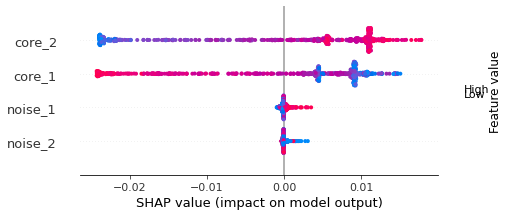

In [86]:
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)
shap.plots.beeswarm(shap_values)

In [87]:
shap.plots.force(shap_values[target_pos])

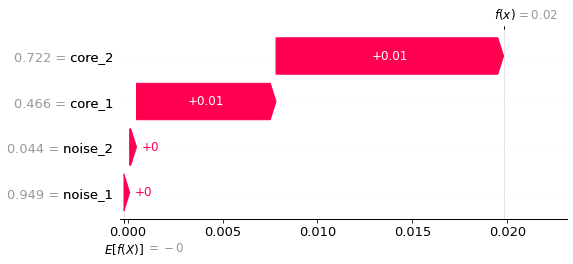

In [88]:
shap.plots.waterfall(shap_values[target_pos])

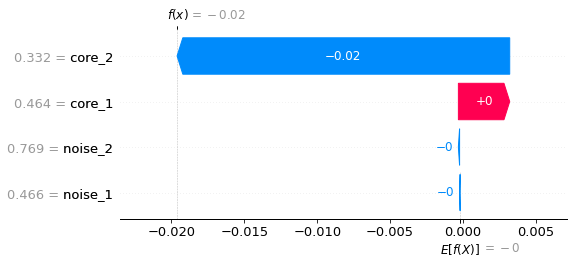

In [89]:
shap.plots.waterfall(shap_values[target_pos2])

# FAR Magnitude

In [545]:
# test considering p_matrix generated from no_i no_ij abs(difference)

# get the probability matrix
p_matrix_mag= get_p_matrix_mag(num_fts, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_mag= p_matrix_to_stationary_dist(p_matrix_mag)

ft_ranking= pd.Series(stationary_mag, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.498520
core_1     0.458982
noise_2    0.040298
noise_1    0.002200
dtype: float64

In [546]:
p_matrix_mag

array([[0.00000e+00, 6.65784e-05, 2.98023e-07, 0.00000e+00],
       [8.75473e-04, 0.00000e+00, 1.78814e-07, 7.70092e-05],
       [1.90139e-05, 9.23514e-04, 0.00000e+00, 0.00000e+00],
       [1.74046e-05, 8.47638e-04, 1.31130e-06, 0.00000e+00]])

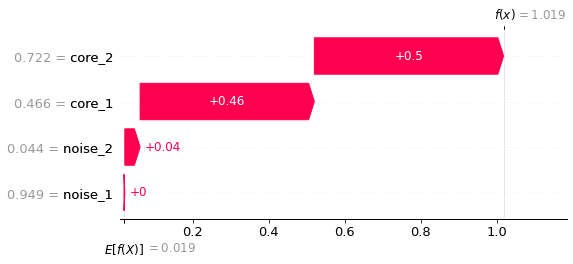

In [547]:
sh_test= to_sh_exp(stationary_mag, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

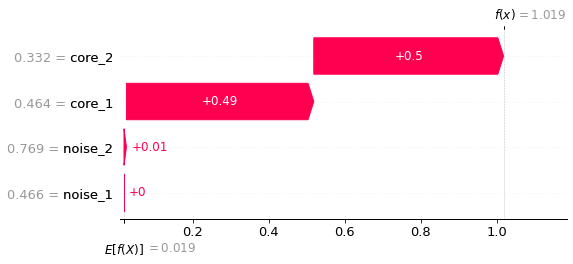

In [548]:
# RELATIVE TO target_inst2
# test considering p_matrix generated from no_i no_ij abs(difference)

# get the probability matrix
p_matrix_mag2= get_p_matrix_mag(num_fts, acc_no_i2, acc_no_ij2)

# get the stationary distribution
stationary_mag2= p_matrix_to_stationary_dist(p_matrix_mag2)

sh_test= to_sh_exp(stationary_mag2, p_base_value, np.asarray(target_inst2)[0], target_inst2.columns)

shap.plots.waterfall(sh_test)

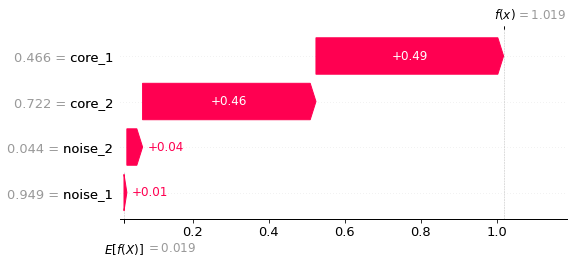

In [549]:
# RELATIVE TO target_inst ADD
# test considering p_matrix generated from no_i no_ij abs(difference)

# get the probability matrix
p_matrix_mag_a= get_p_matrix_mag(num_fts, acc_with_i, acc_with_ij, remove=False)

# get the stationary distribution
stationary_mag_a= p_matrix_to_stationary_dist(p_matrix_mag_a)

sh_test= to_sh_exp(stationary_mag_a, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

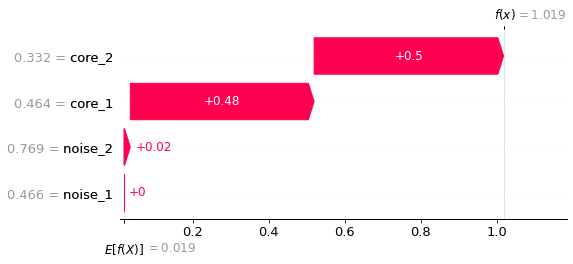

In [550]:
# RELATIVE TO target_inst2 ADD
# test considering p_matrix generated from no_i no_ij abs(difference)

# get the probability matrix
p_matrix_mag_a2= get_p_matrix_mag(num_fts, acc_with_i2, acc_with_ij2)

# get the stationary distribution
stationary_mag_a2= p_matrix_to_stationary_dist(p_matrix_mag_a2)

sh_test= to_sh_exp(stationary_mag_a2, p_base_value, np.asarray(target_inst2)[0], target_inst2.columns)

shap.plots.waterfall(sh_test)

# Divergence (similar to magnitude, target_inst only)

In [551]:
# test considering p_matrix generated from no_i no_ij divergence

# get the probability matrix
p_matrix_div= get_p_matrix_div(num_fts, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_div= p_matrix_to_stationary_dist(p_matrix_div)

ft_ranking= pd.Series(stationary_div, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.499994
core_1     0.496157
noise_2    0.003839
noise_1    0.000010
dtype: float64

In [552]:
p_matrix_div

array([[0.00000e+00, 4.43268e-09, 8.88178e-14, 0.00000e+00],
       [7.66453e-07, 0.00000e+00, 3.19744e-14, 5.93042e-09],
       [3.61528e-10, 8.52879e-07, 0.00000e+00, 0.00000e+00],
       [3.02919e-10, 7.18490e-07, 1.71951e-12, 0.00000e+00]])

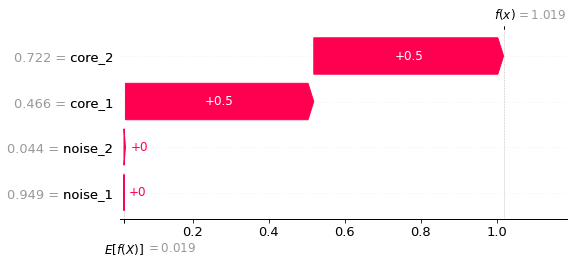

In [553]:
sh_test= to_sh_exp(stationary_div, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

# Difference

In [554]:
# test considering p_matrix generated from no_i no_ij difference

# get the probability matrix
p_matrix_dif= get_p_matrix_dif(num_fts, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_dif= p_matrix_to_stationary_dist(p_matrix_dif)

ft_ranking= pd.Series(stationary_dif, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.354917
core_2     0.249966
noise_2    0.145134
noise_1    0.124854
dtype: float64

In [555]:
p_matrix_dif

array([[ 0.00000e+00, -6.65784e-05,  2.98023e-07,  0.00000e+00],
       [ 8.75473e-04,  0.00000e+00, -1.78814e-07,  7.70092e-05],
       [ 1.90139e-05, -9.23514e-04,  0.00000e+00,  0.00000e+00],
       [ 1.74046e-05, -8.47638e-04, -1.31130e-06,  0.00000e+00]])

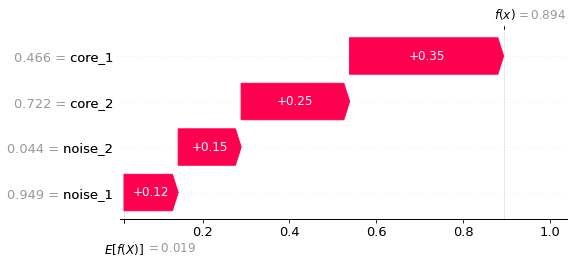

In [556]:
sh_test= to_sh_exp(stationary_dif, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

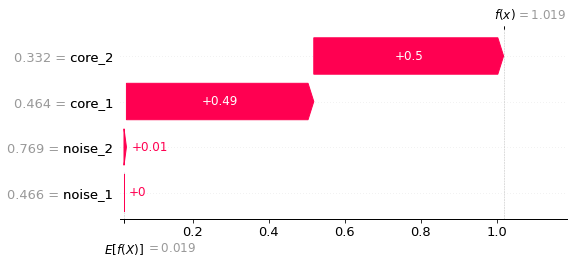

In [557]:
# RELATIVE TO target_inst2
# test considering p_matrix generated from no_i no_ij abs(difference)

# get the probability matrix
p_matrix_dif2= get_p_matrix_dif(num_fts, acc_no_i2, acc_no_ij2)

# get the stationary distribution
stationary_dif2= p_matrix_to_stationary_dist(p_matrix_dif2)

sh_test= to_sh_exp(stationary_dif2, p_base_value, np.asarray(target_inst2)[0], target_inst2.columns)

shap.plots.waterfall(sh_test)

# Split costs from difference - negative and positive values

In [558]:
pos, neg= split_pos_neg_p_matrix(p_matrix_dif)

pos2, neg2= split_pos_neg_p_matrix(p_matrix_dif2)

pos

array([[0.00000e+00, 0.00000e+00, 2.98023e-07, 0.00000e+00],
       [8.75473e-04, 0.00000e+00, 0.00000e+00, 7.70092e-05],
       [1.90139e-05, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       [1.74046e-05, 0.00000e+00, 0.00000e+00, 0.00000e+00]])

In [559]:
neg

array([[ 0.00000e+00, -6.65784e-05,  0.00000e+00,  0.00000e+00],
       [ 0.00000e+00,  0.00000e+00, -1.78814e-07,  0.00000e+00],
       [ 0.00000e+00, -9.23514e-04,  0.00000e+00,  0.00000e+00],
       [ 0.00000e+00, -8.47638e-04, -1.31130e-06,  0.00000e+00]])

In [560]:
p_matrix_dif_diag = p_matrix_dif.copy()
p_matrix_dif_diag2= p_matrix_dif2.copy()

for i in range(num_fts):
    p_matrix_dif_diag[i][i]= err_no_i[i]
    p_matrix_dif_diag2[i][i]= err_no_i[i]

pos_diag, neg_diag= split_pos_neg_p_matrix(p_matrix_dif_diag)
pos_diag2, neg_diag2= split_pos_neg_p_matrix(p_matrix_dif_diag2)

p_matrix_dif_diag

array([[ 5.04683e-01, -6.65784e-05,  2.98023e-07,  0.00000e+00],
       [ 8.75473e-04,  5.03741e-01, -1.78814e-07,  7.70092e-05],
       [ 1.90139e-05, -9.23514e-04,  5.04664e-01,  0.00000e+00],
       [ 1.74046e-05, -8.47638e-04, -1.31130e-06,  5.04665e-01]])

In [561]:
# get the stationary distribution positive
pos_stationary= p_matrix_to_stationary_dist(pos)

pos_ft_ranking= pd.Series(pos_stationary, index=train.columns).sort_values(ascending=False)
pos_ft_ranking

core_1     5.000000e-01
noise_1    5.000000e-01
noise_2    3.966145e-17
core_2     3.896623e-17
dtype: float64

In [562]:
# get the stationary distribution positive
pos_stationary2= p_matrix_to_stationary_dist(pos2)

pos_ft_ranking= pd.Series(pos_stationary2, index=train.columns).sort_values(ascending=False)
pos_ft_ranking

core_2     5.000000e-01
core_1     4.935551e-01
noise_2    6.444877e-03
noise_1    5.192979e-18
dtype: float64

In [563]:
# get the stationary distribution positive
pos_stationary_diag= p_matrix_to_stationary_dist(pos_diag)

pos_ft_ranking= pd.Series(pos_stationary_diag, index=train.columns).sort_values(ascending=False)
pos_ft_ranking

core_1     9.845679e-01
noise_1    1.543213e-02
noise_2    8.479948e-09
core_2     2.096479e-10
dtype: float64

In [564]:
# get the stationary distribution positive
pos_stationary_diag2= p_matrix_to_stationary_dist(pos_diag2)

pos_ft_ranking= pd.Series(pos_stationary_diag2, index=train.columns).sort_values(ascending=False)
pos_ft_ranking

core_2     9.207923e-01
core_1     7.809724e-02
noise_2    1.110475e-03
noise_1    3.236839e-13
dtype: float64

In [565]:
# get the stationary distribution - NEGATIVE SIDE
neg_stationary= p_matrix_to_stationary_dist(np.abs(neg)) # note abs use

neg_ft_ranking= pd.Series(neg_stationary, index=train.columns).sort_values(ascending=False)
neg_ft_ranking

core_2     0.5
noise_1    0.5
core_1     0.0
noise_2    0.0
dtype: float64

In [566]:
# get the stationary distribution - NEGATIVE SIDE
neg_stationary2= p_matrix_to_stationary_dist(np.abs(neg2)) # note abs use

neg_ft_ranking= pd.Series(neg_stationary2, index=train.columns).sort_values(ascending=False)
neg_ft_ranking

core_1     5.000000e-01
noise_2    5.000000e-01
core_2     2.112049e-16
noise_1    9.378470e-17
dtype: float64

In [567]:
# get the stationary distribution - NEGATIVE SIDE
neg_stationary_diag= p_matrix_to_stationary_dist(np.abs(neg_diag)) # note abs use

neg_ft_ranking= pd.Series(neg_stationary_diag, index=train.columns).sort_values(ascending=False)
neg_ft_ranking

core_2     0.5
noise_1    0.5
core_1     0.0
noise_2    0.0
dtype: float64

In [568]:
# get the stationary distribution - NEGATIVE SIDE
neg_stationary_diag2= p_matrix_to_stationary_dist(np.abs(neg_diag2)) # note abs use

neg_ft_ranking= pd.Series(neg_stationary_diag2, index=train.columns).sort_values(ascending=False)
neg_ft_ranking

core_1     5.000000e-01
noise_2    5.000000e-01
core_2     2.112049e-16
noise_1    9.378470e-17
dtype: float64

# --- FAR Explainer ---

In [576]:
# model is a treined classifier
# data is a preprocessed Pandas DataFrame -- model's training data
# labels are the data labels
# target_i and target_l are the instance to be explained and its label, both pd.DataFrame
# replace_type is the type of transformation related to the numerical colums of data

# RETURN the target instance stationary distribution, its Feature Attribution Ranking explanation and 
#        a SHAP formatted explanation -- It is a local explanation

def far_explainer(model, data, labels, target_i, target_l, replace_type="mean", merge_type="mean", 
                  zeroDiag:bool=True, regularization:bool=True, shapley:bool=False, verbose:bool=False):
    
    start= time.time()
    
    n_fts= len(data.columns)
    
    replace_ft= replace_values(data, data.columns, num_type=replace_type, cat_type='none')
    
    # e_fx can be understood as the average model output across the training set X when Xi is not known
    # for this reason, the data mean is used
    e_fx= expected_value_x_mean(model, replace_ft, labels.values.ravel())
    #e_fx=expected_value(model, data, labels.values.ravel())
    #e_fx=expected_value_v2(model, data, labels.values.ravel())
    #e_fx=get_avg_pred_proba(model, data, model.predict(data))
    
    # fx_pred is the model predicted class output from the instance under explanation
    fx_pred= model.predict(target_i)
    # fx is the model probability output from the instance under explanation
    fx= get_avg_pred_proba(model, target_i, fx_pred)
    
    # classifier and remove/add-based costs/gains
    no_i, no_ij, with_i, with_ij= far_gen_costs(model, n_fts, replace_ft, target_i, target_l, fx, fx_pred,
                                                use_preds=True, verbose=False)
    
    if (shapley==False):
        # get the probability matrix - REMOVE and MAGNITUDE
        p_matrix_r_mag= get_p_matrix_mag(n_fts, no_i, no_ij, remove=True, zeroDiag=zeroDiag)
        # get the stationary distribution - REMOVE and MAGNITUDE
        stationary_r_mag= p_matrix_to_stationary_dist(p_matrix_r_mag, version=1)
        # get the probability matrix - REMOVE and DIFFERENCE
        p_matrix_r_dif= get_p_matrix_dif(n_fts, no_i, no_ij, remove=True, zeroDiag=zeroDiag)
        
        
        # get the probability matrix - ADD and MAGNITUDE
        p_matrix_a_mag= get_p_matrix_mag(n_fts, with_i, with_ij, remove=False, zeroDiag=zeroDiag)
        # get the stationary distribution - ADD and MAGNITUDE
        stationary_a_mag= p_matrix_to_stationary_dist(p_matrix_a_mag, version=1)
        # get the probability matrix - ADD and DIFFERENCE
        p_matrix_a_dif= get_p_matrix_dif(n_fts, with_i, with_ij, remove=False, zeroDiag=zeroDiag)
    else:
        # get the first row shapley values to fi - REMOVE
        sh_r_phi_i= get_vector_phi_i(n_fts, e_fx, no_i)
        # get the second row shapley values to fij - REMOVE
        sh_r_phi_ij= get_matrix_phi_ij(n_fts, e_fx, no_i, no_ij)
        # get the probability matrix magnitude between fij and fi - REMOVE
        p_matrix_r_mag= get_sh_p_matrix(n_fts, sh_r_phi_i, sh_r_phi_ij, mag=True, zeroDiag=zeroDiag)
        # get the stationary distribution - FROM MAG VALUES - REMOVE
        stationary_r_mag= p_matrix_to_stationary_dist(p_matrix_r_mag, version=1)
        # get the probability matrix difference between fij and fi - REMOVE
        p_matrix_r_dif= get_sh_p_matrix(n_fts, sh_r_phi_i, sh_r_phi_ij, mag=False, zeroDiag=zeroDiag)
        
        
        # get the first row shapley values to fi - ADD
        sh_a_phi_i= get_vector_phi_i(n_fts, e_fx, with_i)
        # get the second row shapley values to fij - ADD
        sh_a_phi_ij= get_matrix_phi_ij(n_fts, e_fx, with_i, with_ij)
        # get the probability matrix magnitude between fij and fi - ADD
        p_matrix_a_mag= get_sh_p_matrix(n_fts, sh_a_phi_i, sh_a_phi_ij, mag=True, zeroDiag=zeroDiag)
        # get the stationary distribution - FROM MAG VALUES - ADD
        stationary_a_mag= p_matrix_to_stationary_dist(p_matrix_a_mag, version=1)
        # get the probability matrix difference between fij and fi - ADD
        p_matrix_a_dif= get_sh_p_matrix(n_fts, sh_a_phi_i, sh_a_phi_ij, mag=False, zeroDiag=zeroDiag)
        
    if (verbose==True):
        print("Target instance: ")
        print(target_i)
        print("\nNo i classifier run: ")
        print(no_i)
        print("\nNo ij classifier run: ")
        print(np.asarray(no_ij))
        print("\nDifference p_matrix: ")
        print(p_matrix_r_dif)
        
        print("\nNo i classifier run: ")
        print(with_i)
        print("\nNo ij classifier run: ")
        print(np.asarray(with_ij))
        print("\nDifference p_matrix: ")
        print(p_matrix_a_dif)
    
    effect_i= effect_direction(n_fts, p_matrix_r_dif, p_matrix_a_dif)
    
    # split between positive and negative costs from difference p_matrix - REMOVE
    pos_r, neg_r= split_pos_neg_p_matrix(p_matrix_r_dif)
    # split between positive and negative costs from difference p_matrix - ADD
    pos_a, neg_a= split_pos_neg_p_matrix(p_matrix_a_dif)
    
    # get the stationary distribution - POSITIVE - REMOVE
    pos_r_stationary= p_matrix_to_stationary_dist(pos_r, version=1)
    # get the stationary distribution - NEGATIVE - REMOVE
    neg_r_stationary= p_matrix_to_stationary_dist(np.abs(neg_r), version=1) # note abs use
    
    # get the stationary distribution - POSITIVE - ADD
    pos_a_stationary= p_matrix_to_stationary_dist(pos_a, version=1)
    # get the stationary distribution - NEGATIVE - ADD
    neg_a_stationary= p_matrix_to_stationary_dist(np.abs(neg_a), version=1) # note abs use
    
    if (verbose==True):
        print("\nPositive p_matrix - REMOVE: ")
        print(pos_r)
        print("\nNegative p_matrix - REMOVE: ")
        print(neg_r)
        print("\nFeature importances form magnitude - REMOVE: ")
        print(np.around(stationary_r_mag, decimals=3))
        print("\nFeature importances form positive side - REMOVE: ")
        print(np.around(pos_r_stationary, decimals=3))
        print("\nFeature importances form negative side - REMOVE: ")
        print(np.around(neg_r_stationary, decimals=3))
        
        print("\nPositive p_matrix - ADD: ")
        print(pos_a)
        print("\nNegative p_matrix - ADD: ")
        print(neg_a)
        print("\nFeature importances form magnitude - ADD: ")
        print(np.around(stationary_a_mag, decimals=3))
        print("\nFeature importances form positive side - ADD: ")
        print(np.around(pos_a_stationary, decimals=3))
        print("\nFeature importances form negative side - ADD: ")
        print(np.around(neg_a_stationary, decimals=3))
        
        print("\nGeneral effect over i: ")
        print(np.around(effect_i, decimals=3))
    
    
    stationary_final= merge_pos_neg_stationary(pos_r_stationary, neg_r_stationary, stationary_r_mag, 
                                               pos_a_stationary, neg_a_stationary, stationary_a_mag, 
                                               effect_i, merge_type=merge_type)
    
    if (regularization==True):
        stationary_final= ft_ranking_regularization(stationary_final)
        
    if (verbose==True):
        print("\nFeature importances merged: ")
        print(np.around(stationary_final, decimals=5))
   
    stationary_final= rectified_feature_ranking(e_fx, fx, stationary_final)

    ft_ranking= pd.Series(stationary_final, index=data.columns).sort_values(ascending=False)
    
    sh_exp= to_sh_exp(stationary_final, e_fx, np.asarray(target_i)[0], target_i.columns)
    
    if (verbose==True):
        print("\nFeature importances rectified: ")
        print(np.around(stationary_final, decimals=5))
        end= time.time()
        print("\n--- %s seconds ---" % np.round((end- start), 2))

    return stationary_final, ft_ranking, sh_exp

In [572]:
# return a vector containing the effect signal of each variable
# a gain (cost) REMOVING a variable j indicates that j has a NEGATIVE (POSITIVE) effect over a variable i
# a gain (cost)  ADDING  a variable j indicates that j has a POSITIVE (NEGATIVE) effect over a variable i

# gain - when p_matrix[i][j] > 0
# cost - when p_matrix[i][j] < 0

# p_matrix_r obtained from removing processes
# p_matrix_a obtained form  adding  processes

def effect_direction(n_fts, p_matrix_r, p_matrix_a):
    
    signals= []
    
    for i in range(n_fts):
        total_i= 0
        total_i= np.sum(p_matrix_a[i]) - np.sum(p_matrix_r[i])
        
        if (total_i< 0):
            signals.append(-1) # here the variable will receive a negative general effect
        else:
            signals.append(1)  # here the variable will receive a positive general effect
            
    return np.asarray(signals)

In [573]:
# return the stationary distribution from remove and add processes merged
# _r are the positive, negative, ang magnitude stationary from REMOVE
# _a are the positive, negative, ang magnitude stationary from ADD

def merge_pos_neg_stationary(pos_r, neg_r, mag_r, pos_a, neg_a, mag_a, signals=1, merge_type="sum"):
    pos_r= np.abs(pos_r)
    neg_r= np.abs(neg_r)
    mag_r= np.abs(mag_r)
    pos_a= np.abs(pos_a)    # ensure we are working only with positive values
    neg_a= np.abs(neg_a)
    mag_a= np.abs(mag_a)
    
    size= mag_r.shape[0]
    sum_r= np.zeros(size)
    sum_a= np.zeros(size)
    
    if (merge_type=="distance"):
        
        merged= []
        
        for i in range(size):
            
            dn_mag_r_p= np.abs(neg_r[i]+mag_r[i])  # here we used a concept based on absolute distance
            dp_mag_r_p= np.abs(pos_r[i]-mag_r[i])  # between negative and posivite stationary
            
            dn_mag_r_n= np.abs(neg_r[i]-mag_r[i])  # mag_p means the magnitude comes from the positive side
            dp_mag_r_n= np.abs(pos_r[i]+mag_r[i])  # mag_n means the magnitude comes from the negative side
            
            dn_mag_a_p= np.abs(neg_a[i]+mag_a[i])
            dp_mag_a_p= np.abs(pos_a[i]-mag_a[i])
            
            dn_mag_a_n= np.abs(neg_a[i]-mag_a[i])
            dp_mag_a_n= np.abs(pos_a[i]+mag_a[i])
            
            if (signals[i]< 0):   # we are in mag negative side
                sum_r[i]= (dp_mag_r_p - dn_mag_r_p)*mag_r[i]
                sum_a[i]= (dp_mag_a_p - dn_mag_a_p)*mag_a[i]
            else:                 # we are in mag positive side
                sum_r[i]= (dp_mag_r_n - dn_mag_r_n)*mag_r[i]
                sum_a[i]= (dp_mag_a_n - dn_mag_a_n)*mag_a[i]
            
            merged= (sum_r+ sum_a)/2
            
        return merged
    
    elif (merge_type=="weighted"):    # here we made a weighted sum of elements of mag according to 
                                      # neg and pos stationary.
        residual= []
            
        for i in range(size):         
            
            if (pos_r[i]!= neg_r[i]):        # the largest value will determine the signal
                sum_r[i]= (pos_r[i]*mag_r[i] - neg_r[i]*mag_r[i])
            else:
                sum_r[i]= pos_r[i]*mag_r[i]  # when pos[i]==neg[i] we have an uncertainty adjusted later
                
            if (pos_a[i]!= neg_a[i]):
                sum_a[i]= (pos_a[i]*mag_a[i] - neg_a[i]*mag_a[i])
            else:
                sum_a[i]= pos_a[i]*mag_a[i]
                
            check_sum= (pos_r[i] + pos_a[i] + neg_r[i] + neg_a[i])
            
            if (check_sum== 0):    # if positive and negative stationary are zero but magnitude is not
                residual.append(mag_r[i]+mag_a[i])  # the before weighted sum will be zero, then we
            else:                                   # save a residual from the magnitudes
                residual.append(0) # if not, this residual is zero
                    
        merged= (sum_r+ sum_a+ residual)/2
        
        for i in range(size):  # this adjust is done to correct the uncertainty we have when pos[i]==neg[i]
            
            if ((merged[i]< 0 and signals[i]> 0) or (merged[i]> 0 and signals[i]< 0)):
                merged[i]= -merged[i]

        return merged
    
    elif (merge_type=="effect"):
        
        eff_pos= (pos_r + pos_a)   # a gain (cost)  ADDING  indicates a POSITIVE (NEGATIVE) effect
        eff_neg= (neg_a + neg_r)   # a gain (cost) REMOVING indicates a NEGATIVE (POSITIVE) effect
    
        merged = (mag_r + mag_a)
        
        for i in range(size):
            
            if (eff_neg[i]> eff_pos[i]):
                merged[i]= (-merged[i] -merged[i]*eff_neg[i] +merged[i]*eff_pos[i])
            else:
                merged[i]= (+merged[i] +merged[i]*eff_pos[i] -merged[i]*eff_neg[i])
        
        return merged
    
    if (merge_type=='effect2'):           # idea
                                          # gain REMOVING -> NEGATIVE effect, then
        gain= np.zeros(size)              #  -> neg > pos -> gain
        cost= np.zeros(size)              #  -> pos > neg -> cost
        
        merged= np.zeros(size)            # gain  ADDING  -> POSITIVE effect 
                                          #  -> pos > neg -> gain
                                          #  -> neg > pos -> cost                                 
        for i in range(size):
            gain[i]= mag_r[i]*neg_r[i] + mag_a[i]*pos_a[i]
            cost[i]= mag_r[i]*pos_r[i] + mag_a[i]*neg_a[i]
                
            if (gain[i]>= cost[i]):       # TODO
                merged[i]= +(mag_a[i]*(pos_a[i] - neg_a[i]) + mag_r[i]*(neg_r[i] - pos_r[i]))
            else:
                merged[i]= -(mag_a[i]*(neg_a[i] - pos_a[i]) + mag_r[i]*(pos_r[i] - neg_r[i]))
        
        return merged        
    
    mag_mean= (mag_r + mag_a)/2
    pos= pos_r + pos_a
    neg= neg_r + neg_a
    
    for i in range(size):
        
        if (neg[i]> pos[i]):
            mag_mean[i]= -mag_mean[i]
    
    return mag_mean

In [574]:
# here we convert the final stationary distribution (post positive and negative merge) into a 
# feature contribution values based on the instance prediction

def rectified_feature_ranking(e_fx, fx, stationary_final):
    
    lo_e_fx= pred_proba_to_log_odds(e_fx)
    lo_fx= pred_proba_to_log_odds(fx)
    
    distance= np.abs(lo_e_fx - lo_fx)
    rect_ft_ranking= []
    
    if (lo_e_fx < lo_fx):    # here we have a prediction value greater than the expected value, 
                             # then sum(stationary)> 0 because features sum must increase to the mean value
        if not (np.sum(stationary_final)> 0):
            rect_ft_ranking= -(stationary_final.copy())  # rectification step to fix a signal mismatch
        else:
            rect_ft_ranking= stationary_final.copy()
        
    elif (lo_e_fx >= lo_fx):
    
        if not (np.sum(stationary_final)< 0):
            rect_ft_ranking= -(stationary_final.copy())  # rectification step to fix a signal mismatch
        else:
            rect_ft_ranking= stationary_final.copy()
    
    # transform percent values from stationary [0,1] into distance values accordind to e_fx and fx        
    #distance_max= stationary_final[np.argmax(np.abs(stationary_final))]
    distance_stat= np.abs(np.sum(rect_ft_ranking))
    eps= 0.01
    distance_stat= np.clip(distance_stat, eps, None)
    
    d_ratio= distance/distance_stat
    d_ratio= np.clip(d_ratio, None, 2*distance)
    
    #print(lo_e_fx)
    #print(lo_fx)

    dist_ft_ranking= d_ratio*rect_ft_ranking
            
    return dist_ft_ranking

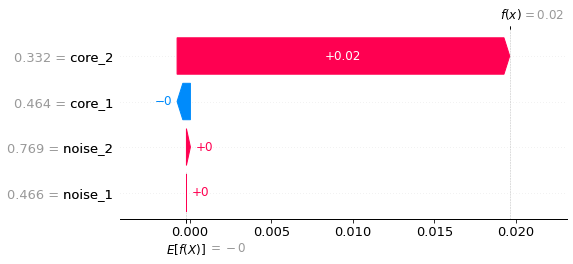

In [577]:
data_pos= 9

target_i= train.iloc[data_pos].to_frame().T
target_l= labels_train.iloc[data_pos].to_frame().T

stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l, 
                                replace_type="mean", merge_type="distance", 
                                zeroDiag=False, regularization=True, shapley=False, verbose=False)

#print(stat)

shap.plots.waterfall(sh_e)


--- 93.74 seconds ---


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


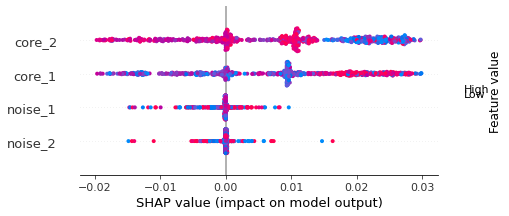

In [578]:
start= time.time()

train_size= train.shape[0]

stationary_values= []

for i in range(train_size):
    #print(i)
    
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="mean", merge_type="distance", 
                                    zeroDiag=False, regularization=True, shapley=False, verbose=False)
    
    #shap.plots.waterfall(sh_e)
    
    stationary_values.append(stat)
    
base_vector= []
base_vector= [p_base_value for i in range(train_size)]

far_exp= to_sh_exp(np.asarray(stationary_values), np.asarray(base_vector), np.asarray(train), 
                          train.columns)

end= time.time()
print("\n--- %s seconds ---" % np.round((end- start), 2))

shap.plots.beeswarm(far_exp)

In [2283]:
# Tests varying the important parameters

#   mean (_me)   distance (_d)   zeroDiag False (_zf)   shapley False (_sf)
# median (_mn)   weighted (_w)   zeroDiag True  (_zt)   shapley True  (_st)
#  zeros (_ze)        sum (_s)

In [2646]:
start= time.time()

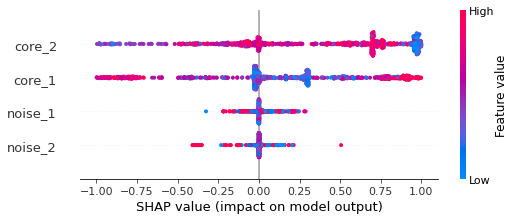

In [2647]:
# far explanation - replace_type="mean", merge_type="distance", zeroDiag=False, shapley=False

stationary_values_me_d_zf_sf = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="mean", merge_type="distance", 
                                    zeroDiag=False, regularization=True, shapley=False, verbose=False)
    
    stationary_values_me_d_zf_sf.append(stat)
    
far_exp_me_d_zf_sf = to_sh_exp(np.asarray(stationary_values_me_d_zf_sf), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_me_d_zf_sf)

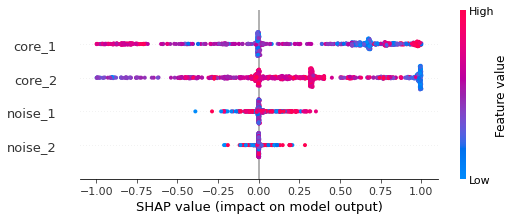

In [2648]:
# far explanation - replace_type="median", merge_type="distance", zeroDiag=False, shapley=False

stationary_values_mn_d_zf_sf = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="median", merge_type="distance", 
                                    zeroDiag=False, regularization=True, shapley=False, verbose=False)
    
    stationary_values_mn_d_zf_sf.append(stat)
    
far_exp_mn_d_zf_sf = to_sh_exp(np.asarray(stationary_values_mn_d_zf_sf), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_mn_d_zf_sf)

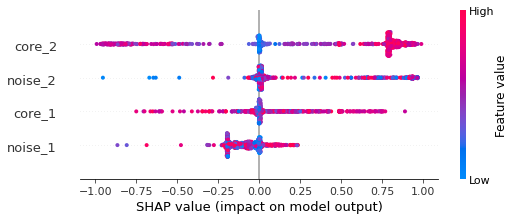

In [2649]:
# far explanation - replace_type="zeros", merge_type="distance", zeroDiag=False, shapley=False

stationary_values_ze_d_zf_sf = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="zeros", merge_type="distance", 
                                    zeroDiag=False, regularization=True, shapley=False, verbose=False)
    
    stationary_values_ze_d_zf_sf.append(stat)
    
far_exp_ze_d_zf_sf = to_sh_exp(np.asarray(stationary_values_ze_d_zf_sf), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_ze_d_zf_sf)

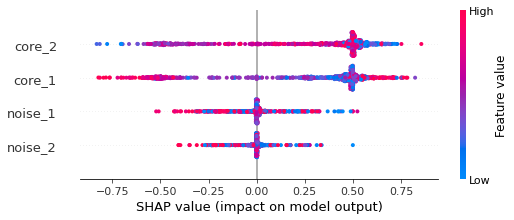

In [2650]:
# far explanation - replace_type="mean", merge_type="distance", zeroDiag=True, shapley=False

stationary_values_me_d_zt_sf = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="mean", merge_type="distance", 
                                    zeroDiag=True, regularization=True, shapley=False, verbose=False)
    
    stationary_values_me_d_zt_sf.append(stat)
    
far_exp_me_d_zt_sf = to_sh_exp(np.asarray(stationary_values_me_d_zt_sf), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_me_d_zt_sf)

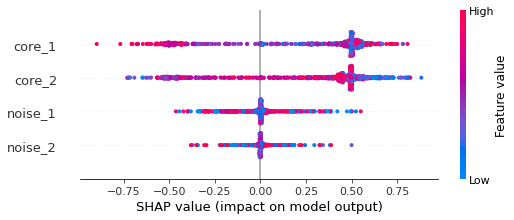

In [2651]:
# far explanation - replace_type="median", merge_type="distance", zeroDiag=True, shapley=False

stationary_values_mn_d_zt_sf = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="median", merge_type="distance", 
                                    zeroDiag=True, regularization=True, shapley=False, verbose=False)
    
    stationary_values_mn_d_zt_sf.append(stat)
    
far_exp_mn_d_zt_sf = to_sh_exp(np.asarray(stationary_values_mn_d_zt_sf), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_mn_d_zt_sf)

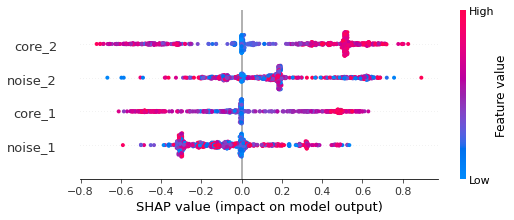

In [2652]:
# far explanation - replace_type="zeros", merge_type="distance", zeroDiag=True, shapley=False

stationary_values_ze_d_zt_sf = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="zeros", merge_type="distance", 
                                    zeroDiag=True, regularization=True, shapley=False, verbose=False)
    
    stationary_values_ze_d_zt_sf.append(stat)
    
far_exp_ze_d_zt_sf = to_sh_exp(np.asarray(stationary_values_ze_d_zt_sf), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_ze_d_zt_sf)

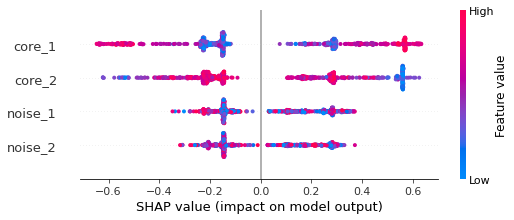

In [2653]:
# far explanation - replace_type="mean", merge_type="distance", zeroDiag=False, shapley=True

stationary_values_me_d_zf_st = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="mean", merge_type="distance", 
                                    zeroDiag=False, regularization=True, shapley=True, verbose=False)
    
    stationary_values_me_d_zf_st.append(stat)
    
far_exp_me_d_zf_st = to_sh_exp(np.asarray(stationary_values_me_d_zf_st), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_me_d_zf_st)

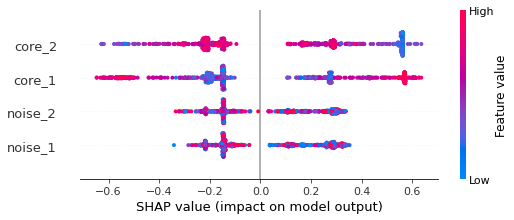

In [2654]:
# far explanation - replace_type="median", merge_type="distance", zeroDiag=False, shapley=True

stationary_values_mn_d_zf_st = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="median", merge_type="distance", 
                                    zeroDiag=False, regularization=True, shapley=True, verbose=False)
    
    stationary_values_mn_d_zf_st.append(stat)
    
far_exp_mn_d_zf_st = to_sh_exp(np.asarray(stationary_values_mn_d_zf_st), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_mn_d_zf_st)

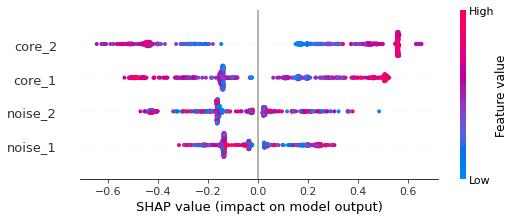

In [2655]:
# far explanation - replace_type="zeros", merge_type="distance", zeroDiag=False, shapley=True

stationary_values_ze_d_zf_st = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="zeros", merge_type="distance", 
                                    zeroDiag=False, regularization=True, shapley=True, verbose=False)
    
    stationary_values_ze_d_zf_st.append(stat)
    
far_exp_ze_d_zf_st = to_sh_exp(np.asarray(stationary_values_ze_d_zf_st), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_ze_d_zf_st)

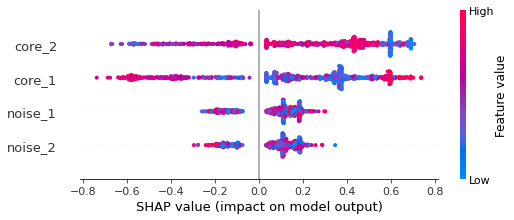

In [2656]:
# far explanation - replace_type="mean", merge_type="distance", zeroDiag=True, shapley=True

stationary_values_me_d_zt_st = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="mean", merge_type="distance", 
                                    zeroDiag=True, regularization=True, shapley=True, verbose=False)
    
    stationary_values_me_d_zt_st.append(stat)
    
far_exp_me_d_zt_st = to_sh_exp(np.asarray(stationary_values_me_d_zt_st), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_me_d_zt_st)

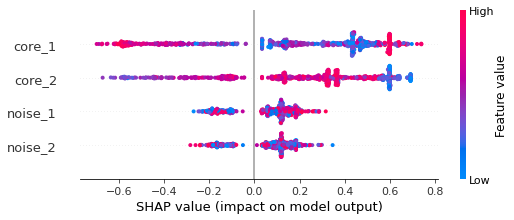

In [2657]:
# far explanation - replace_type="median", merge_type="distance", zeroDiag=True, shapley=True

stationary_values_mn_d_zt_st = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="median", merge_type="distance", 
                                    zeroDiag=True, regularization=True, shapley=True, verbose=False)
    
    stationary_values_mn_d_zt_st.append(stat)
    
far_exp_mn_d_zt_st = to_sh_exp(np.asarray(stationary_values_mn_d_zt_st), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_mn_d_zt_st)

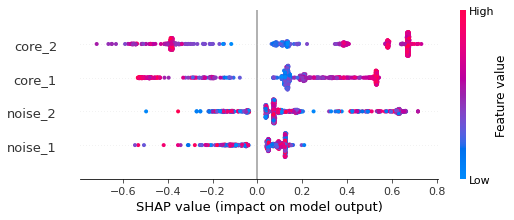

In [2658]:
# far explanation - replace_type="zeros", merge_type="distance", zeroDiag=True, shapley=True

stationary_values_ze_d_zt_st = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="zeros", merge_type="distance", 
                                    zeroDiag=True, regularization=True, shapley=True, verbose=False)
    
    stationary_values_ze_d_zt_st.append(stat)
    
far_exp_ze_d_zt_st = to_sh_exp(np.asarray(stationary_values_ze_d_zt_st), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_ze_d_zt_st)

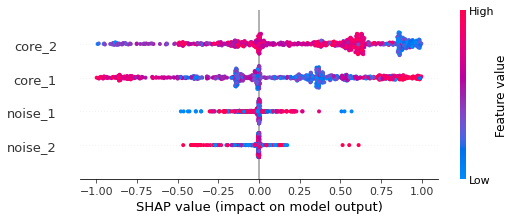

In [2659]:
# far explanation - replace_type="mean", merge_type="weighted", zeroDiag=False, shapley=False

stationary_values_me_w_zf_sf = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="mean", merge_type="weighted", 
                                    zeroDiag=False, regularization=True, shapley=False, verbose=False)
    
    stationary_values_me_w_zf_sf.append(stat)
    
far_exp_me_w_zf_sf = to_sh_exp(np.asarray(stationary_values_me_w_zf_sf), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_me_w_zf_sf)

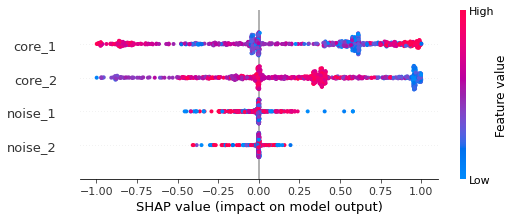

In [2660]:
# far explanation - replace_type="median", merge_type="weighted", zeroDiag=False, shapley=False

stationary_values_mn_w_zf_sf = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="median", merge_type="weighted", 
                                    zeroDiag=False, regularization=True, shapley=False, verbose=False)
    
    stationary_values_mn_w_zf_sf.append(stat)
    
far_exp_mn_w_zf_sf = to_sh_exp(np.asarray(stationary_values_mn_w_zf_sf), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_mn_w_zf_sf)

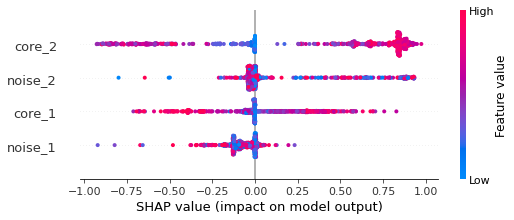

In [2661]:
# far explanation - replace_type="zeros", merge_type="weighted", zeroDiag=False, shapley=False

stationary_values_ze_w_zf_sf = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="zeros", merge_type="weighted", 
                                    zeroDiag=False, regularization=True, shapley=False, verbose=False)
    
    stationary_values_ze_w_zf_sf.append(stat)
    
far_exp_ze_w_zf_sf = to_sh_exp(np.asarray(stationary_values_ze_w_zf_sf), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_ze_w_zf_sf)

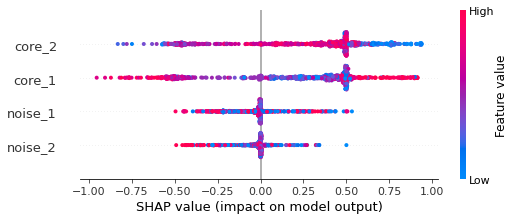

In [2662]:
# far explanation - replace_type="mean", merge_type="weighted", zeroDiag=True, shapley=False

stationary_values_me_w_zt_sf = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="mean", merge_type="weighted", 
                                    zeroDiag=True, regularization=True, shapley=False, verbose=False)
    
    stationary_values_me_w_zt_sf.append(stat)
    
far_exp_me_w_zt_sf = to_sh_exp(np.asarray(stationary_values_me_w_zt_sf), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_me_w_zt_sf)

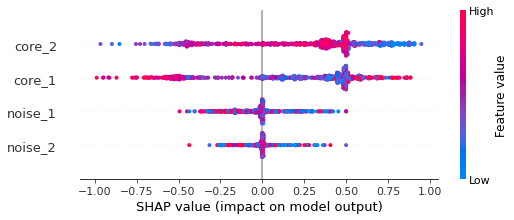

In [2663]:
# far explanation - replace_type="median", merge_type="weighted", zeroDiag=True, shapley=False

stationary_values_mn_w_zt_sf = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="median", merge_type="weighted", 
                                    zeroDiag=True, regularization=True, shapley=False, verbose=False)
    
    stationary_values_mn_w_zt_sf.append(stat)
    
far_exp_mn_w_zt_sf = to_sh_exp(np.asarray(stationary_values_mn_w_zt_sf), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_mn_w_zt_sf)

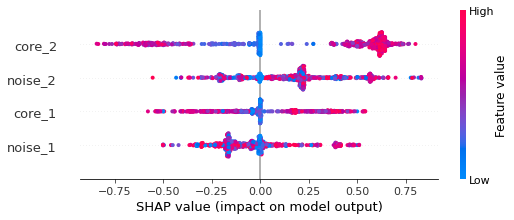

In [2664]:
# far explanation - replace_type="zeros", merge_type="weighted", zeroDiag=True, shapley=False

stationary_values_ze_w_zt_sf = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="zeros", merge_type="weighted", 
                                    zeroDiag=True, regularization=True, shapley=False, verbose=False)
    
    stationary_values_ze_w_zt_sf.append(stat)
    
far_exp_ze_w_zt_sf = to_sh_exp(np.asarray(stationary_values_ze_w_zt_sf), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_ze_w_zt_sf)

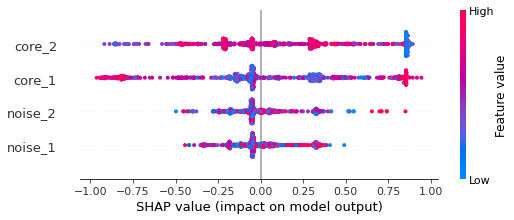

In [2665]:
# far explanation - replace_type="mean", merge_type="weighted", zeroDiag=False, shapley=True

stationary_values_me_w_zf_st = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="mean", merge_type="weighted", 
                                    zeroDiag=False, regularization=True, shapley=True, verbose=False)
    
    stationary_values_me_w_zf_st.append(stat)
    
far_exp_me_w_zf_st = to_sh_exp(np.asarray(stationary_values_me_w_zf_st), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_me_w_zf_st)

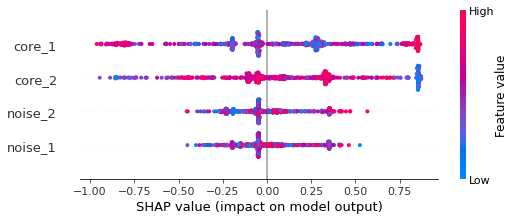

In [2666]:
# far explanation - replace_type="median", merge_type="weighted", zeroDiag=False, shapley=True

stationary_values_mn_w_zf_st = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="median", merge_type="weighted", 
                                    zeroDiag=False, regularization=True, shapley=True, verbose=False)
    
    stationary_values_mn_w_zf_st.append(stat)
    
far_exp_mn_w_zf_st = to_sh_exp(np.asarray(stationary_values_mn_w_zf_st), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_mn_w_zf_st)

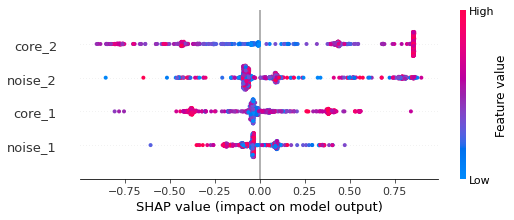

In [2667]:
# far explanation - replace_type="zeros", merge_type="weighted", zeroDiag=False, shapley=True

stationary_values_ze_w_zf_st = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="zeros", merge_type="weighted", 
                                    zeroDiag=False, regularization=True, shapley=True, verbose=False)
    
    stationary_values_ze_w_zf_st.append(stat)
    
far_exp_ze_w_zf_st = to_sh_exp(np.asarray(stationary_values_ze_w_zf_st), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_ze_w_zf_st)

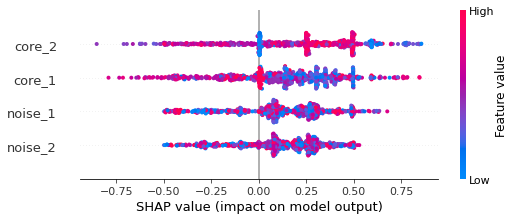

In [2668]:
# far explanation - replace_type="mean", merge_type="weighted", zeroDiag=True, shapley=True

stationary_values_me_w_zt_st = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="mean", merge_type="weighted", 
                                    zeroDiag=True, regularization=True, shapley=True, verbose=False)
    
    stationary_values_me_w_zt_st.append(stat)
    
far_exp_me_w_zt_st = to_sh_exp(np.asarray(stationary_values_me_w_zt_st), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_me_w_zt_st)

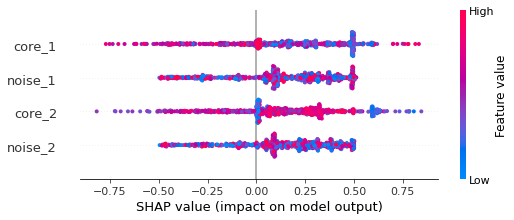

In [2669]:
# far explanation - replace_type="median", merge_type="weighted", zeroDiag=True, shapley=True

stationary_values_mn_w_zt_st = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="median", merge_type="weighted", 
                                    zeroDiag=True, regularization=True, shapley=True, verbose=False)
    
    stationary_values_mn_w_zt_st.append(stat)
    
far_exp_mn_w_zt_st = to_sh_exp(np.asarray(stationary_values_mn_w_zt_st), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_mn_w_zt_st)

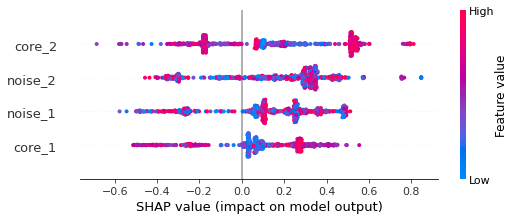

In [2670]:
# far explanation - replace_type="zeros", merge_type="weighted", zeroDiag=True, shapley=True

stationary_values_ze_w_zt_st = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="zeros", merge_type="weighted", 
                                    zeroDiag=True, regularization=True, shapley=True, verbose=False)
    
    stationary_values_ze_w_zt_st.append(stat)
    
far_exp_ze_w_zt_st = to_sh_exp(np.asarray(stationary_values_ze_w_zt_st), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_ze_w_zt_st)

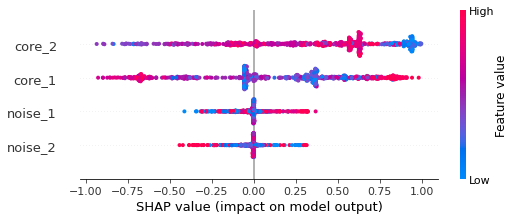

In [2671]:
# far explanation - replace_type="mean", merge_type="sum", zeroDiag=False, shapley=False

stationary_values_me_s_zf_sf = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="mean", merge_type="sum", 
                                    zeroDiag=False, regularization=True, shapley=False, verbose=False)
    
    stationary_values_me_s_zf_sf.append(stat)
    
far_exp_me_s_zf_sf = to_sh_exp(np.asarray(stationary_values_me_s_zf_sf), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_me_s_zf_sf)

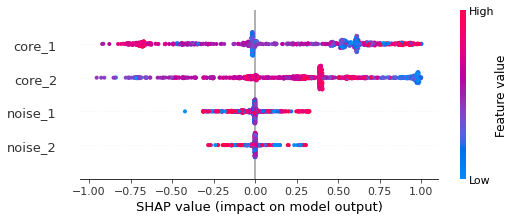

In [2672]:
# far explanation - replace_type="median", merge_type="sum", zeroDiag=False, shapley=False

stationary_values_mn_s_zf_sf = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="median", merge_type="sum", 
                                    zeroDiag=False, regularization=True, shapley=False, verbose=False)
    
    stationary_values_mn_s_zf_sf.append(stat)
    
far_exp_mn_s_zf_sf = to_sh_exp(np.asarray(stationary_values_mn_s_zf_sf), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_mn_s_zf_sf)

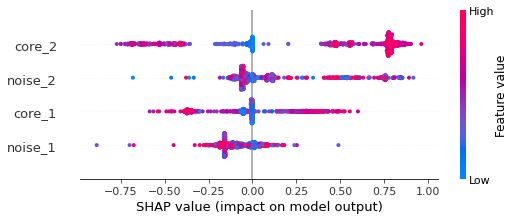

In [2673]:
# far explanation - replace_type="zeros", merge_type="sum", zeroDiag=False, shapley=False

stationary_values_ze_s_zf_sf = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="zeros", merge_type="sum", 
                                    zeroDiag=False, regularization=True, shapley=False, verbose=False)
    
    stationary_values_ze_s_zf_sf.append(stat)
    
far_exp_ze_s_zf_sf = to_sh_exp(np.asarray(stationary_values_ze_s_zf_sf), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_ze_s_zf_sf)

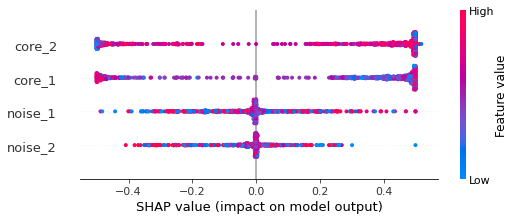

In [2674]:
# far explanation - replace_type="mean", merge_type="sum", zeroDiag=True, shapley=False

stationary_values_me_s_zt_sf = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="mean", merge_type="sum", 
                                    zeroDiag=True, regularization=True, shapley=False, verbose=False)
    
    stationary_values_me_s_zt_sf.append(stat)
    
far_exp_me_s_zt_sf = to_sh_exp(np.asarray(stationary_values_me_s_zt_sf), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_me_s_zt_sf)

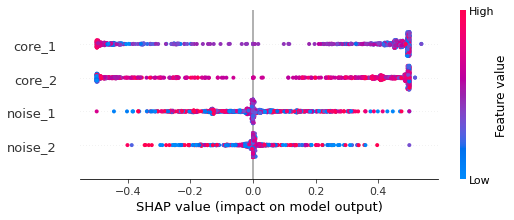

In [2675]:
# far explanation - replace_type="median", merge_type="sum", zeroDiag=True, shapley=False

stationary_values_mn_s_zt_sf = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="median", merge_type="sum", 
                                    zeroDiag=True, regularization=True, shapley=False, verbose=False)
    
    stationary_values_mn_s_zt_sf.append(stat)
    
far_exp_mn_s_zt_sf = to_sh_exp(np.asarray(stationary_values_mn_s_zt_sf), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_mn_s_zt_sf)

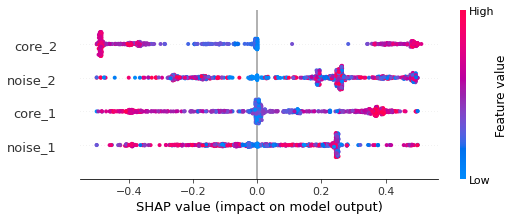

In [2676]:
# far explanation - replace_type="zeros", merge_type="sum", zeroDiag=True, shapley=False

stationary_values_ze_s_zt_sf = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="zeros", merge_type="sum", 
                                    zeroDiag=True, regularization=True, shapley=False, verbose=False)
    
    stationary_values_ze_s_zt_sf.append(stat)
    
far_exp_ze_s_zt_sf = to_sh_exp(np.asarray(stationary_values_ze_s_zt_sf), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_ze_s_zt_sf)

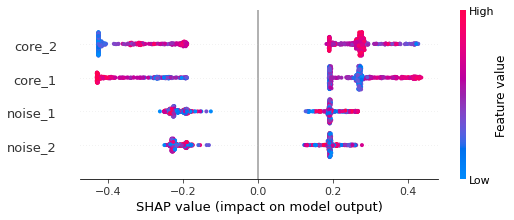

In [2677]:
# far explanation - replace_type="mean", merge_type="sum", zeroDiag=False, shapley=True

stationary_values_me_s_zf_st = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="mean", merge_type="sum", 
                                    zeroDiag=False, regularization=True, shapley=True, verbose=False)
    
    stationary_values_me_s_zf_st.append(stat)
    
far_exp_me_s_zf_st = to_sh_exp(np.asarray(stationary_values_me_s_zf_st), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_me_s_zf_st)

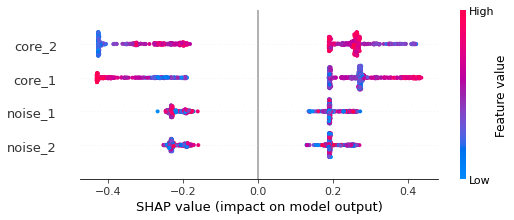

In [2678]:
# far explanation - replace_type="median", merge_type="sum", zeroDiag=False, shapley=True

stationary_values_mn_s_zf_st = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="median", merge_type="sum", 
                                    zeroDiag=False, regularization=True, shapley=True, verbose=False)
    
    stationary_values_mn_s_zf_st.append(stat)
    
far_exp_mn_s_zf_st = to_sh_exp(np.asarray(stationary_values_mn_s_zf_st), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_mn_s_zf_st)

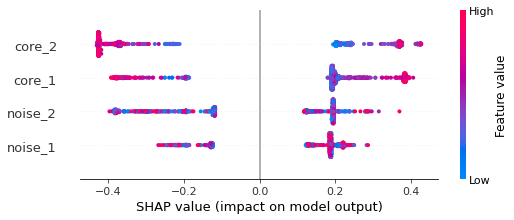

In [2679]:
# far explanation - replace_type="zeros", merge_type="sum", zeroDiag=False, shapley=True

stationary_values_ze_s_zf_st = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="zeros", merge_type="sum", 
                                    zeroDiag=False, regularization=True, shapley=True, verbose=False)
    
    stationary_values_ze_s_zf_st.append(stat)
    
far_exp_ze_s_zf_st = to_sh_exp(np.asarray(stationary_values_ze_s_zf_st), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_ze_s_zf_st)

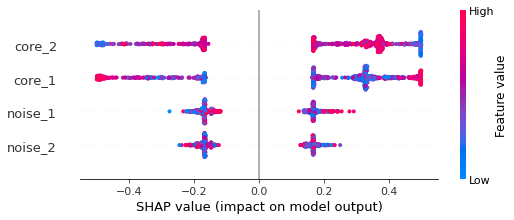

In [2680]:
# far explanation - replace_type="mean", merge_type="sum", zeroDiag=True, shapley=True

stationary_values_me_s_zt_st = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="mean", merge_type="sum", 
                                    zeroDiag=True, regularization=True, shapley=True, verbose=False)
    
    stationary_values_me_s_zt_st.append(stat)
    
far_exp_me_s_zt_st = to_sh_exp(np.asarray(stationary_values_me_s_zt_st), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_me_s_zt_st)

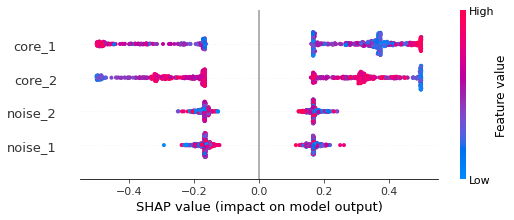

In [2681]:
# far explanation - replace_type="median", merge_type="sum", zeroDiag=True, shapley=True

stationary_values_mn_s_zt_st = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="median", merge_type="sum", 
                                    zeroDiag=True, regularization=True, shapley=True, verbose=False)
    
    stationary_values_mn_s_zt_st.append(stat)
    
far_exp_mn_s_zt_st = to_sh_exp(np.asarray(stationary_values_mn_s_zt_st), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_mn_s_zt_st)

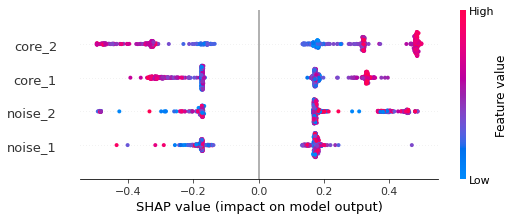

In [2682]:
# far explanation - replace_type="zeros", merge_type="sum", zeroDiag=True, shapley=True

stationary_values_ze_s_zt_st = []

for i in range(train_size):
    target_i= train.iloc[i].to_frame().T
    target_l= labels_train.iloc[i].to_frame().T

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, target_i, target_l,
                                    replace_type="zeros", merge_type="sum", 
                                    zeroDiag=True, regularization=True, shapley=True, verbose=False)
    
    stationary_values_ze_s_zt_st.append(stat)
    
far_exp_ze_s_zt_st = to_sh_exp(np.asarray(stationary_values_ze_s_zt_st), np.asarray(base_vector), 
                              np.asarray(train), train.columns)

shap.plots.beeswarm(far_exp_ze_s_zt_st)

In [2683]:
end= time.time()
print("\n--- %s seconds ---" % np.round((end- start), 2))


--- 6942.92 seconds ---


# --- Benchmarks --- 

In [ ]:
#!git clone https://github.com/AI4LIFE-GROUP/OpenXAI.git
!{sys.executable} -m pip install -e OpenXAI

In [95]:
import openxai

# Utils
import torch
import pickle

# ML models
from openxai.LoadModel import LoadModel

# Data loaders
from openxai.dataloader import return_loaders

# Explanation models
from openxai.Explainer import Explainer

# Evaluation methods
from openxai.evaluator import Evaluator

# Perturbation methods required for the computation of the relative stability metrics
from openxai.explainers.catalog.perturbation_methods import NormalPerturbation
from openxai.explainers.catalog.perturbation_methods import NewDiscrete_NormalPerturbation

In [96]:
data_name='synthetic'

gauss_params = {'n_samples': 1000,
                'dim': 20,
                'n_clusters': 10,
                'distance_to_center': 5,
                'test_size': 0.20,
                'upper_weight': 1,
                'lower_weight': -1,
                'seed': 564,
                'sigma': None,
                'sparsity': 0.25
                }

# Get training and test loaders
loader_train, loader_test= return_loaders(data_name=data_name, 
                                          download=True, 
                                          batch_size=1000, 
                                          scaler='minmax', 
                                          gauss_params=gauss_params)

data_it= iter(loader_train)

inputs, labels, sy_weights, sy_masks, sy_masked_weights, sy_probs, sy_cluster_idx= data_it.next()
labels= labels.type(torch.int64)

inputs.shape

torch.Size([1000, 20])

# Tests using LIME from OpenXAI

In [102]:
# Load pretrained ml model
model = LoadModel(data_name=data_name, ml_model='ann', pretrained=True)

# You can also use the default hyperparameters likes so:
lime_e = Explainer(method='lime',
                 model=model,
                 dataset_tensor=inputs,
                 param_dict_lime=None)

lime_exp= lime_e.get_explanation(inputs.float(), label=labels)

100%|██████████| 2000/2000 [01:17<00:00, 25.66it/s]


In [127]:
# Perturbation class parameters
perturbation_mean = 0.0
perturbation_std = 0.10
perturbation_flip_percentage = 0.03

if data_name == 'compas':
    feature_types = ['c', 'd', 'c', 'c', 'd', 'd', 'd']
# Gaussian feature types
elif data_name == 'synthetic':
    feature_types = ['c'] * 20
# Heloc feature types
elif data_name == 'heloc':
    feature_types = ['c'] * 23

    
perturbation = NormalPerturbation("tabular",
                                  mean=perturbation_mean,
                                  std_dev=perturbation_std,
                                  flip_percentage=perturbation_flip_percentage)

def generate_mask(explanation, top_k):
    mask_indices = torch.topk(explanation, top_k).indices
    mask = torch.zeros(explanation.shape) > 10
    for i in mask_indices:
        mask[i] = True
    return mask


input_dict = dict()
index = 5

# inputs and models
input_dict['x'] = inputs[index].reshape(-1)
input_dict['input_data'] = inputs
input_dict['explainer'] = lime_e
input_dict['explanation_x'] = lime_exp[index,:].flatten()
input_dict['model'] = model

# perturbation method used for the stability metric
input_dict['perturbation'] = perturbation
input_dict['perturb_method'] = perturbation
input_dict['perturb_max_distance'] = 0.4
input_dict['feature_metadata'] = feature_types
input_dict['p_norm'] = 2
input_dict['eval_metric'] = None

# true label, predicted label, and masks
input_dict['top_k'] = 3
input_dict['y'] = labels[index].detach().item()
input_dict['y_pred'] = torch.max(model(inputs[index].unsqueeze(0).float()), 1).indices.detach().item()
input_dict['mask'] = generate_mask(input_dict['explanation_x'].reshape(-1), input_dict['top_k'])

# required for the representation stability measure
input_dict['L_map'] = model

evaluator = Evaluator(input_dict, inputs=inputs, labels=labels, model=model, explainer=lime_e)

In [128]:
if hasattr(model, 'return_ground_truth_importance'):
    # evaluate rank correlation
    print('RC:', evaluator.evaluate(metric='RC'))

    # evaluate feature agreement
    print('FA:', evaluator.evaluate(metric='FA'))

    # evaluate rank agreement
    print('RA:', evaluator.evaluate(metric='RA'))

    # evaluate sign agreement
    print('SA:', evaluator.evaluate(metric='SA'))

    # evaluate signed rankcorrelation
    print('SRA:', evaluator.evaluate(metric='SRA'))

# evaluate prediction gap on umportant features
print('PGU:', evaluator.evaluate(metric='PGU'))

# evaluate prediction gap on important features
print('PGI:', evaluator.evaluate(metric='PGI'))

# evaluate relative input stability
print('RIS:', evaluator.evaluate(metric='RIS'))

# evaluate relative output stability
print('ROS:', evaluator.evaluate(metric='ROS'))

PGU: 0.0
PGI: 1.1920929e-09


100%|██████████| 1/1 [00:00<00:00, 22.99it/s]


RIS: 914.7003367009241


100%|██████████| 1/1 [00:00<00:00, 25.01it/s]


ROS: 1.1667141143212696e+17


In [129]:
inputs

tensor([[0.1843, 0.4025, 0.2830,  ..., 0.5456, 0.3695, 0.6715],
        [0.2832, 0.2923, 0.3076,  ..., 0.6855, 0.4551, 0.2991],
        [0.3658, 0.3171, 0.3977,  ..., 0.5106, 0.3729, 0.6025],
        ...,
        [0.3963, 0.2142, 0.2597,  ..., 0.6003, 0.5245, 0.3843],
        [0.6047, 0.2995, 0.3742,  ..., 0.5280, 0.6069, 0.5369],
        [0.1496, 0.2641, 0.4229,  ..., 0.5968, 0.4649, 0.3624]],
       dtype=torch.float64)

# Benchmark methods --- Our versions ---

In [444]:
import lime
import lime.lime_tabular

# Relative Input/Output Stability
# model is a treined classifier
# data is a preprocessed Pandas DataFrame -- model's training data
# labels are the data labels (Pandas DataFrame)
# perturbation is a OpenXAI perturbation object
# descriptor define the parameters to explanations and data perturbations

# approximates the maximum L-p distance between explanations in a neighborhood around input x
# RETURN RIS (ris=True) or ROS (ris=False) metric for FAR, SHAP, and LIME.
# max_mean=True RETURN RIS/ROS max stability ratios value, 
# max_mean=False RETURN RIS/ROS mean stability ratios value

def relative_stability(model, data, labels, perturbation, descriptor, ris:bool=True, max_mean:bool=True):
    
    tensor_train= torch.from_numpy(data.values)
    tensor_labels= torch.from_numpy(labels.values.ravel().astype(int))
    
    # ------------ data reduction for testing
    tensor_train = tensor_train[0:10, :]
    tensor_labels= tensor_labels[0:10]
    # ---------------------------------------
    
    far_stability_ratios= []
    shap_stability_ratios= []
    lime_stability_ratios= []
    
    for i_data, x_data in enumerate(tensor_train):
        # here x_data is tensor_train[i_data]

        # data point prediction
        y_pred= torch.from_numpy(model.predict(np.asarray(x_data.unsqueeze(0))))

        # x_data and its label as pd.DataFrame
        target_i= pd.DataFrame(x_data, data.columns).T
        target_l= pd.DataFrame(data=[np.int64(tensor_labels[i_data])], columns=labels.columns)
        
        far_x_stability_ratios= []
        shap_x_stability_ratios= []
        lime_x_stability_ratios= []

        # ------------------------------------ x_data explanation
        # data point explanation -- FAR
        far_x_exp, far_x_ft, far_x_sh= far_explainer(model, data, labels, target_i, target_l, 
                                                     replace_type=descriptor['replace_type'], 
                                                     merge_type=descriptor['merge_type'], 
                                                     zeroDiag=descriptor['zeroDiag'], 
                                                     regularization=descriptor['regularization'], 
                                                     shapley=descriptor['shapley'], verbose=False)

        far_x_exp= torch.from_numpy(far_x_exp)


        # data point explanation -- SHAP
        shap_exp_gen= shap.Explainer(model, data)
        shap_x_exp= shap_exp_gen(target_i)

        shap_x_exp= (torch.from_numpy(shap_x_exp.values)).squeeze()


        # data point explanation -- LIME
        lime_exp_gen= lime.lime_tabular.LimeTabularExplainer(np.asarray(train), 
                                                             feature_names=np.asarray(train.columns), 
                                                             class_names=np.asarray([0,1]), verbose=False, 
                                                             mode='classification', 
                                                             discretize_continuous=False)

        lime_scores= lime_exp_gen.explain_instance(np.asarray(target_i)[0], model.predict_proba, 
                                                     num_features=train.shape[1])

        lime_x_exp= torch.from_numpy(lime_exp_in_data_order(lime_scores, train.shape[1]))

        # ------------------------------------ x_data perturbation
        # data point perturbation
        x_pert_samples= perturbation.get_perturbed_inputs(original_sample=x_data,
                                                          feature_mask=descriptor['mask'],
                                                          num_samples=descriptor['num_samples'],
                                                          max_distance=descriptor['pert_max_distance'],
                                                          feature_metadata=descriptor['feature_metadata'])

        # take the first num_perts points that have the same predicted class label
        y_pert_preds= torch.from_numpy(model.predict(x_pert_samples.numpy()))

        ind_same_class= (y_pert_preds == y_pred).nonzero()[: descriptor['num_perts']].squeeze()
        x_pert_samples= torch.index_select(input=x_pert_samples, dim=0, index=ind_same_class)

        y_pert_preds= torch.from_numpy(model.predict(x_pert_samples.numpy()))

        # ------------------------------------ explain each x_data perturbation
        far_exp_pert_samples= torch.zeros_like(x_pert_samples)
        shap_exp_pert_samples= torch.zeros_like(x_pert_samples)
        lime_exp_pert_samples= torch.zeros_like(x_pert_samples)

        # For each perturbation, calculate the explanation
        for i, x_pert in enumerate(x_pert_samples):

            target_i= pd.DataFrame(x_pert, data.columns).T
            target_l= pd.DataFrame(data=[np.int64(y_pert_preds[i])], columns=labels.columns)

            # perturbed data point explanation -- FAR
            far_exp, far_ft, far_sh= far_explainer(model, data, labels, target_i, target_l, 
                                                   replace_type=descriptor['replace_type'], 
                                                   merge_type=descriptor['merge_type'], 
                                                   zeroDiag=descriptor['zeroDiag'], 
                                                   regularization=descriptor['regularization'], 
                                                   shapley=descriptor['shapley'], verbose=False)

            far_exp_pert_samples[i, :]= torch.from_numpy(far_exp)

            # perturbed data point explanation -- SHAP
            shap_exp= shap_exp_gen(target_i)
            shap_exp_pert_samples[i, :]= torch.from_numpy(shap_exp.values)

            # perturbed data point explanation -- LIME
            lime_scores= lime_exp_gen.explain_instance(np.asarray(target_i)[0], model.predict_proba, 
                                                       num_features=train.shape[1])

            lime_exp_pert_samples[i, :]= torch.from_numpy(lime_exp_in_data_order(lime_scores, train.shape[1]))

        # ------------------------------------ compute stability for each explanator and x_data perturbation
        for sample_i, x_pert in enumerate(x_pert_samples):

            if (ris==True):
                far_stability_measure= ris_measure(x_data, x_pert, 
                                                   far_x_exp, far_exp_pert_samples[sample_i], 
                                                   p_norm=descriptor['p_norm'], eps=descriptor['eps'])

                shap_stability_measure= ris_measure(x_data, x_pert, 
                                                    shap_x_exp, shap_exp_pert_samples[sample_i], 
                                                    p_norm=descriptor['p_norm'], eps=descriptor['eps'])

                lime_stability_measure= ris_measure(x_data, x_pert, 
                                                    lime_x_exp, lime_exp_pert_samples[sample_i], 
                                                    p_norm=descriptor['p_norm'], eps=descriptor['eps'])
            else:
                x_pert= x_pert.unsqueeze(0)

                far_stability_measure= ros_measure(model, x_data.unsqueeze(0), x_pert, 
                                                   far_x_exp, far_exp_pert_samples[sample_i], 
                                                   p_norm=descriptor['p_norm'], eps=descriptor['eps'])

                shap_stability_measure= ros_measure(model, x_data.unsqueeze(0), x_pert, 
                                                    shap_x_exp, shap_exp_pert_samples[sample_i], 
                                                    p_norm=descriptor['p_norm'], eps=descriptor['eps'])

                lime_stability_measure= ros_measure(model, x_data.unsqueeze(0), x_pert, 
                                                    lime_x_exp, lime_exp_pert_samples[sample_i], 
                                                    p_norm=descriptor['p_norm'], eps=descriptor['eps'])
            
            # stability measures for each x_data perturbation -- a processing
            far_x_stability_ratios.append(far_stability_measure)
            shap_x_stability_ratios.append(shap_stability_measure)
            lime_x_stability_ratios.append(lime_stability_measure)
        
        # append only the max/mean value related to each x_data processed
        if (max_mean==True):
            far_stability_ratios.append(far_x_stability_ratios[np.argmax(far_x_stability_ratios)])
            shap_stability_ratios.append(shap_x_stability_ratios[np.argmax(shap_x_stability_ratios)])
            lime_stability_ratios.append(lime_x_stability_ratios[np.argmax(lime_x_stability_ratios)])
        else:
            far_stability_ratios.append(np.mean(far_x_stability_ratios))
            shap_stability_ratios.append(np.mean(shap_x_stability_ratios))
            lime_stability_ratios.append(np.mean(lime_x_stability_ratios))
        
    # ------------------------------------ RETURN ratios considering all data processed
    if (max_mean==True):
        far_max = far_stability_ratios[np.argmax(far_stability_ratios)]
        shap_max= shap_stability_ratios[np.argmax(shap_stability_ratios)]
        lime_max= lime_stability_ratios[np.argmax(lime_stability_ratios)]
        
        # max stability_ratios
        return far_max, shap_max, lime_max
    
    far_mean = np.mean(far_stability_ratios)
    shap_mean= np.mean(shap_stability_ratios)
    lime_mean= np.mean(lime_stability_ratios)

    # mean stability_ratios
    return far_mean, shap_mean, lime_mean

In [100]:
# compute norm between predictions per perturbation - RIS

def ris_measure(x_data, x_pert, exp_data, exp_pert, p_norm=2, eps=0.001):
    
    exp_dif= lp_norm_dif(exp_data, exp_pert, p_norm=p_norm, eps=eps)
    
    x_dif= lp_norm_dif(x_data, x_pert, p_norm=p_norm, eps=eps)
    x_dif= np.clip(x_dif, eps, None)

    stability_measure= np.divide(exp_dif, x_dif)
    
    return stability_measure

In [101]:
# compute norm between representations - ROS

def ros_measure(model, x_data, x_pert, exp_data, exp_pert, p_norm=2, eps=0.001):
    
    exp_dif= lp_norm_dif(exp_data, exp_pert, p_norm=p_norm, eps=eps)
    
    h_x_data= model.predict_proba(np.asarray(x_data))
    h_x_pert= model.predict_proba(np.asarray(x_pert))

    h_dif= lp_norm_dif(h_x_data, h_x_pert, p_norm=p_norm, eps=eps)
    h_dif= np.clip(h_dif, eps, None)

    stability_measure= np.divide(exp_dif, h_dif)
    
    return stability_measure

In [102]:
# returns the Lp norm of the difference between v1 and v2.
# normalizes the difference between v1 and v2 by v1 (Agarwal, Chirag, et al., 2022)

def lp_norm_dif(v1, v2, p_norm=2, eps=0.001, norm:bool=True):
    
    # arrays can be flattened, so long as ordering is preserved
    flat_dif= np.asarray(v1).flatten() - np.asarray(v2).flatten()
    
    if (norm==True):
        v1_aux= np.asarray(v1).flatten()
        v1_aux= np.clip(v1_aux, eps, None)
        flat_dif= np.divide(flat_dif, v1_aux, where=v1_aux!= 0)

    return np.linalg.norm(flat_dif, ord=p_norm)

In [103]:
# bring explanations into data order (since LIME automatically orders according to highest importance)

def lime_exp_in_data_order(lime_exp, num_fts):
    
    exp= np.zeros(num_fts)

    for k, v in lime_exp.local_exp[1]:
        exp[k]= v

    return exp

In [104]:
# Testing data and definitions

tensor_train= torch.from_numpy(train.values)
tensor_labels= torch.from_numpy(labels_train.values.ravel().astype(int))

In [395]:
# Perturbation class parameters
perturbation_mean= 0.0
perturbation_std= 0.10
perturbation_flip_percentage= 0.03 
    
perturbation= NormalPerturbation('tabular',
                                 mean=perturbation_mean,
                                 std_dev=perturbation_std,
                                 flip_percentage=perturbation_flip_percentage)

def generate_mask(explanation, top_k):
    mask_indices= torch.topk(explanation, top_k).indices
    mask= torch.zeros(explanation.shape) > 10
    for i in mask_indices:
        mask[i]= True
    return mask

descriptor= dict()

# explanation settings
descriptor['replace_type']= 'mean'
descriptor['merge_type']= 'distance'
descriptor['zeroDiag']= False
descriptor['regularization']= True
descriptor['shapley']= False
# perturbation settings used for the stability metric
descriptor['num_perts']= 50
descriptor['pert_max_distance']= 0.1
descriptor['num_samples']= 100
descriptor['num_runs']= 50
descriptor['eps']= 0.001
descriptor['feature_metadata']= ['c'] * 4
descriptor['p_norm']= 2
descriptor['top_k']= 0
descriptor['mask']= generate_mask(tensor_train[0].reshape(-1), descriptor['top_k'])

In [469]:
# evaluate relative input stability
print('Max RIS -- (FAR, SHAP, LIME) --', 
      relative_stability(xgb_model, train, labels_train, perturbation, descriptor, ris=True, max_mean=True))

Max RIS -- (FAR, SHAP, LIME) -- (321.77985403106925, 68.07097680054792, 2.6957048335163427)


In [277]:
print('Mean RIS -- (FAR, SHAP, LIME) --', 
      relative_stability(xgb_model, train, labels_train, perturbation, descriptor, ris=True, max_mean=False))

Mean RIS -- (FAR, SHAP, LIME) -- (26.66822731981133, 5.0738021796449955, 0.8485345107546755)


In [278]:
# evaluate relative output stability
print('Max ROS -- (FAR, SHAP, LIME) --', 
      relative_stability(xgb_model, train, labels_train, perturbation, descriptor, ris=False, max_mean=True))

Max ROS -- (FAR, SHAP, LIME) -- (44753.281452113326, 17208.31640887009, 1911.0359238537944)


In [279]:
print('Mean ROS -- (FAR, SHAP, LIME) --', 
      relative_stability(xgb_model, train, labels_train, perturbation, descriptor, ris=False, max_mean=False))

Mean ROS -- (FAR, SHAP, LIME) -- (8705.932138787299, 667.7133155152968, 348.8638957257594)


In [439]:
# Run Explanation Stability
# model is a treined classifier
# data is a preprocessed Pandas DataFrame -- model's training data
# labels are the data labels (Pandas DataFrame)
# descriptor define the parameters to explanations and data perturbations

# RETURN a measure of stability (FAR, SHAP, LIME) from multiple runs over non-perturbed x.
# the greater the value, the less stable the method is

def run_stability(model, data, labels, descriptor):
    
    tensor_train= torch.from_numpy(data.values)
    tensor_labels= torch.from_numpy(labels.values.ravel().astype(int))
    
    # ------------ data reduction for testing
    tensor_train = tensor_train[0:10, :]
    tensor_labels= tensor_labels[0:10]
    # ---------------------------------------
    
    far_stability_ratios= []
    shap_stability_ratios= []
    lime_stability_ratios= []
    
    runs= descriptor['num_runs']
    
    for i_data, x_data in enumerate(tensor_train):
        # here x_data is tensor_train[i_data]

        # x_data and its label as pd.DataFrame
        target_i= pd.DataFrame(x_data, data.columns).T
        target_l= pd.DataFrame(data=[np.int64(tensor_labels[i_data])], columns=labels.columns)

        far_x_exps= []
        shap_x_exps= []
        lime_x_exps= []
                               
        for i in range(runs):
            # ------------------------------------ n runs x_data explanation
            # data point explanation -- FAR
            far_x_exp, far_x_ft, far_x_sh= far_explainer(model, data, labels, target_i, target_l, 
                                                         replace_type=descriptor['replace_type'], 
                                                         merge_type=descriptor['merge_type'], 
                                                         zeroDiag=descriptor['zeroDiag'], 
                                                         regularization=descriptor['regularization'], 
                                                         shapley=descriptor['shapley'], verbose=False)

            far_x_exps.append(far_x_exp)

            # data point explanation -- SHAP
            shap_exp_gen= shap.Explainer(model, data)
            shap_x_exp= shap_exp_gen(target_i)

            shap_x_exps.append((shap_x_exp.values).squeeze())

            # data point explanation -- LIME
            lime_exp_gen= lime.lime_tabular.LimeTabularExplainer(np.asarray(train), 
                                                                 feature_names=np.asarray(train.columns), 
                                                                 class_names=np.asarray([0,1]), 
                                                                 verbose=False, mode='classification', 
                                                                 discretize_continuous=False)

            lime_scores= lime_exp_gen.explain_instance(np.asarray(target_i)[0], model.predict_proba, 
                                                         num_features=train.shape[1])

            lime_x_exps.append(lime_exp_in_data_order(lime_scores, train.shape[1]))
            

        far_x_exp_mean= np.mean(far_x_exps, axis=0)
        shap_x_exp_mean= np.mean(shap_x_exps, axis=0)
        lime_x_exp_mean= np.mean(lime_x_exps, axis=0)
        
        far_x_exp_ratios= []
        shap_x_exp_ratios= []
        lime_x_exp_ratios= []

        # ------------------------------------ distance of each explanation from the mean of explanations 
        for i in range(runs):
            far_x_exp_ratios.append(lp_norm_dif(far_x_exps[i], far_x_exp_mean, 
                                                p_norm=descriptor['p_norm'], norm=False))

            shap_x_exp_ratios.append(lp_norm_dif(shap_x_exps[i], shap_x_exp_mean, 
                                                 p_norm=descriptor['p_norm'], norm=False))

            lime_x_exp_ratios.append(lp_norm_dif(lime_x_exps[i], lime_x_exp_mean, 
                                                 p_norm=descriptor['p_norm'], norm=False))

        # ------------------------------------ max ratio related to each x_data
        far_stability_ratios.append(far_x_exp_ratios[np.argmax(far_x_exp_ratios)])
        shap_stability_ratios.append(shap_x_exp_ratios[np.argmax(shap_x_exp_ratios)])
        lime_stability_ratios.append(lime_x_exp_ratios[np.argmax(lime_x_exp_ratios)])
    
    # ------------------------------------ general max ratio related to all data
    far_max = far_stability_ratios[np.argmax(far_stability_ratios)]
    shap_max= shap_stability_ratios[np.argmax(shap_stability_ratios)]
    lime_max= lime_stability_ratios[np.argmax(lime_stability_ratios)]

    # max stability_ratios
    return far_max, shap_max, lime_max

In [209]:
# evaluate explanation stability from multiple runs over non-perturbed data
print('RES -- (FAR, SHAP, LIME) --', run_stability(xgb_model, train, labels_train, descriptor))

RES -- (FAR, SHAP, LIME) -- (5.343962009278975e-17, 2.58126656495041e-17, 0.00036504887692288606)


In [440]:
# Prediction Gap on Important Features (Dai, Jessica, et al., 2022)
# model is a treined classifier
# data is a preprocessed Pandas DataFrame -- model's training data
# labels are the data labels (Pandas DataFrame)
# perturbation is a OpenXAI perturbation object
# descriptor define the parameters to explanations and data perturbations

def eval_pred_faithfulness(model, data, labels, perturbation, descriptor):
    
    tensor_train= torch.from_numpy(data.values)
    tensor_labels= torch.from_numpy(labels.values.ravel().astype(int))
    
    # ------------ data reduction for testing
    #tensor_train = tensor_train[0:10, :]
    #tensor_labels= tensor_labels[0:10]
    # ---------------------------------------
    
    x_pred_faithfulness= []
    
    for i_data, x_data in enumerate(tensor_train):
        # here x_data is tensor_train[i_data]

        # ------------------------------------ x_data perturbation
        # data point perturbation
        x_pert_samples= perturbation.get_perturbed_inputs(original_sample=x_data,
                                                          feature_mask=descriptor['mask'],
                                                          num_samples=descriptor['num_samples'],
                                                          max_distance=descriptor['pert_max_distance'],
                                                          feature_metadata=descriptor['feature_metadata'])

        # ------------------------------------ Average the expected absolute difference    
        # data point prediction
        y_pred= model.predict_proba(np.asarray(x_data.reshape(1, -1).float()))

        # perturbed data points predictions
        y_pert_preds= model.predict_proba(x_pert_samples.numpy())

        x_pred_faithfulness.append(np.mean(np.abs(y_pred - y_pert_preds), axis=0)[0])
    
    pred_faithfulness= x_pred_faithfulness[np.argmax(x_pred_faithfulness)]
    
    return pred_faithfulness

In [112]:
# evaluate prediction gap on important features
print('PGI:', eval_pred_faithfulness(xgb_model, train, labels_train, perturbation, descriptor))

PGI: 0.00571418


In [500]:
# For an additive explanator, the sum of all feature importance values will be equal to the difference
# between the expected value of the model and the predicted value
# That is, Sum(Phi_i) = f(x) - E[f(X)].

# RETURN a measure of faithfulness for additive explanators over non-perturbed dataset (mean value).
# the greater the value, the less faithful the method is

def eval_additive_exp_faithfulness(model, data, labels, descriptor, max_mean:bool=False):
    
    tensor_train= torch.from_numpy(data.values)
    tensor_labels= torch.from_numpy(labels.values.ravel().astype(int))
    
    # ------------ data reduction for testing
    #tensor_train = tensor_train[9:10, :]
    #tensor_labels= tensor_labels[9:10]
    # ---------------------------------------
    
    far_faith= []
    shap_faith= []
    
    for i_data, x_data in enumerate(tensor_train):
        # here x_data is tensor_train[i_data]
        
        # x_data and its label as pd.DataFrame
        target_i= pd.DataFrame(x_data, data.columns).T
        target_l= pd.DataFrame(data=[np.int64(tensor_labels[i_data])], columns=labels.columns)
        
        # data point prediction
        y_pred= model.predict(target_i)

        lo_fx= pred_proba_to_log_odds(model.predict_proba(target_i)[0][y_pred])[0]
        
        
        # ------------------------------------ x_data explanation
        # data point explanation -- FAR
        far_x_exp, far_x_ft, far_x_sh= far_explainer(model, data, labels, target_i, target_l, 
                                                     replace_type=descriptor['replace_type'], 
                                                     merge_type=descriptor['merge_type'], 
                                                     zeroDiag=descriptor['zeroDiag'], 
                                                     regularization=descriptor['regularization'], 
                                                     shapley=descriptor['shapley'], verbose=False)
        
        far_e_fx= far_x_sh.base_values
        far_sum_values= np.sum(far_x_ft)
        
        # Sum(Phi_i) = f(x) - E[f(X)]
        far_fx= far_e_fx + far_sum_values
        
        far_faith.append(lp_norm_dif(lo_fx, far_fx, p_norm=descriptor['p_norm'], 
                                     eps=descriptor['eps'], norm=True))


        # data point explanation -- SHAP
        shap_exp_gen= shap.Explainer(model, data)
        shap_x_exp= shap_exp_gen(target_i)

        shap_e_fx= shap_x_exp.base_values[0]
        shap_sum_values= np.sum(shap_x_exp.values)
        
        # Sum(Phi_i) = f(x) - E[f(X)]
        shap_fx= shap_e_fx + shap_sum_values
        
        shap_faith.append(lp_norm_dif(lo_fx, shap_fx, p_norm=descriptor['p_norm'], 
                                      eps=descriptor['eps'], norm=True))
        
    # ------------------------------------ RETURN mean faithfulness
    if (max_mean==True):
        far_max = far_faith[np.argmax(far_faith)]
        shap_max= shap_faith[np.argmax(shap_faith)]
        
        return far_max, shap_max
        
    far_mean = np.mean(far_faith)
    shap_mean= np.mean(shap_faith)
    
    return far_mean, shap_mean

In [499]:
# evaluate the mean faithfulness of an additive explanator
print('AEF -- (FAR, SHAP) --', eval_additive_exp_faithfulness(xgb_model, train, labels_train, descriptor))

AEF -- (FAR, SHAP) -- (0.10073483477656155, 1.022770359554013)


# Tests using Synthetic data from OpenXAI

In [217]:
data_name='synthetic'

gauss_params= {'n_samples': 1000,
               'dim': 20,
               'n_clusters': 10,
               'distance_to_center': 5,
               'test_size': 0.20,
               'upper_weight': 1,
               'lower_weight': -1,
               'seed': 564,
               'sigma': None,
               'sparsity': 0.25
               }

# Get training and test loaders
loader_train, loader_test= return_loaders(data_name=data_name, 
                                          download=True, 
                                          batch_size=500, 
                                          scaler='minmax', 
                                          gauss_params=gauss_params)

data_it= iter(loader_train)

inputs, labels, sy_weights, sy_masks, sy_masked_weights, sy_probs, sy_cluster_idx= data_it.next()
labels= labels.type(torch.int64)

In [218]:
inputs

tensor([[0.7667, 0.1547, 0.1633,  ..., 0.6014, 0.4116, 0.5140],
        [0.3158, 0.2712, 0.2268,  ..., 0.4359, 0.5135, 0.5315],
        [0.2056, 0.3128, 0.6509,  ..., 0.5610, 0.4772, 0.5981],
        ...,
        [0.3488, 0.2795, 0.3589,  ..., 0.8148, 0.4388, 0.4058],
        [0.4166, 0.2534, 0.6787,  ..., 0.5641, 0.5006, 0.5568],
        [0.2179, 0.3438, 0.5225,  ..., 0.6494, 0.4305, 1.0000]],
       dtype=torch.float64)

In [501]:
# TODO
# define descriptor parameters considering inputs synthetic data
# train the ML model on inputs
# test

# Different versions of p_matrix

# Shapley values i and ij

In [1144]:
# test considering p_matrix generated from shapley values i row and ij row

# get the first row shapley values to fi
sh_phi_i= get_vector_phi_i(num_fts, p_base_value, acc_no_i)

# get the second row shapley values to fij
sh_phi_ij= get_matrix_phi_ij(num_fts, p_base_value, acc_no_i, acc_no_ij)

# get the probability matrix difference between fij and fi
p_matrix_sh= get_sh_p_matrix(num_fts, sh_phi_i, sh_phi_ij, mag=False, zeroDiag=True)

In [1145]:
sh_phi_i

array([ 7.58823e-05, -1.59631e-04,  7.12034e-05,  7.15312e-05])

In [1146]:
sh_phi_ij

array([[ 0.00000e+00,  1.43290e-04,  7.74916e-05,  7.73327e-05],
       [-9.22226e-05,  0.00000e+00, -2.36605e-04, -2.23850e-04],
       [ 7.28127e-05, -5.77108e-06,  0.00000e+00,  7.10941e-05],
       [ 7.29816e-05,  7.31214e-06,  7.14219e-05,  0.00000e+00]])

In [1147]:
p_matrix_sh

array([[ 0.00000e+00,  6.74079e-05,  1.60933e-06,  1.45038e-06],
       [ 6.74079e-05,  0.00000e+00, -7.69744e-05, -6.42190e-05],
       [ 1.60933e-06, -7.69744e-05,  0.00000e+00, -1.09275e-07],
       [ 1.45038e-06, -6.42190e-05, -1.09275e-07,  0.00000e+00]])

In [1148]:
sh_pos, sh_neg= split_pos_neg_p_matrix(p_matrix_sh)

sh_pos

array([[0.00000e+00, 6.74079e-05, 1.60933e-06, 1.45038e-06],
       [6.74079e-05, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       [1.60933e-06, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       [1.45038e-06, 0.00000e+00, 0.00000e+00, 0.00000e+00]])

In [1149]:
sh_neg

array([[ 0.00000e+00,  0.00000e+00,  0.00000e+00,  0.00000e+00],
       [ 0.00000e+00,  0.00000e+00, -7.69744e-05, -6.42190e-05],
       [ 0.00000e+00, -7.69744e-05,  0.00000e+00, -1.09275e-07],
       [ 0.00000e+00, -6.42190e-05, -1.09275e-07,  0.00000e+00]])

In [1150]:
# get the stationary distribution - FROM MAG VALUES
stationary_sh= p_matrix_to_stationary_dist(np.abs(p_matrix_sh), version=1) # note the use of abs = mag

ft_ranking= pd.Series(stationary_sh, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.492518
noise_1    0.185798
core_1     0.166377
noise_2    0.155307
dtype: float64

In [1151]:
# get the stationary distribution - POSITIVE VALUES
pos_stationary_sh= p_matrix_to_stationary_dist(sh_pos, version=1)

pos_ft_ranking= pd.Series(pos_stationary_sh, index=train.columns).sort_values(ascending=False)
pos_ft_ranking

core_1     0.500000
core_2     0.478290
noise_1    0.011419
noise_2    0.010291
dtype: float64

In [1152]:
# get the stationary distribution - NEGATIVE VALUES
neg_stationary_sh= p_matrix_to_stationary_dist(sh_neg, version=1)

neg_ft_ranking= pd.Series(neg_stationary_sh, index=train.columns).sort_values(ascending=False)
neg_ft_ranking

core_1     0.200023
noise_2    0.199997
noise_1    0.199992
core_2     0.199966
dtype: float64

In [1153]:
st_final= merge_pos_neg_stationary(pos_stationary_sh, neg_stationary_sh, stationary_sh, merge_type="mean")

ft_ranking= pd.Series(st_final, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.256947
core_1     0.155452
noise_1   -0.000925
noise_2   -0.011466
dtype: float64

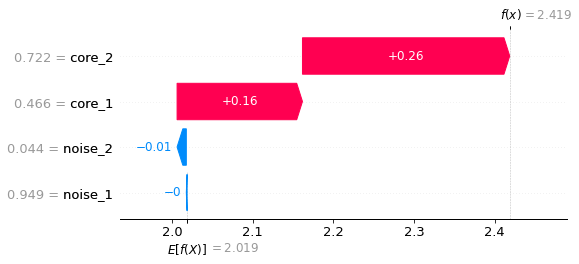

In [1154]:
sh_test= to_sh_exp(st_final, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

In [1155]:
st_final_reg= ft_ranking_regularization(st_final)

ft_ranking_reg= pd.Series(st_final_reg, index=train.columns).sort_values(ascending=False)
ft_ranking_reg

core_2     0.604880
core_1     0.365949
noise_1   -0.002177
noise_2   -0.026993
dtype: float64

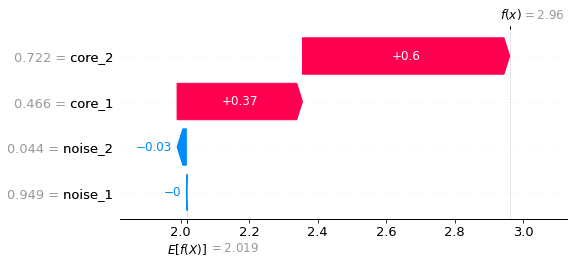

In [1156]:
sh_test= to_sh_exp(st_final_reg, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

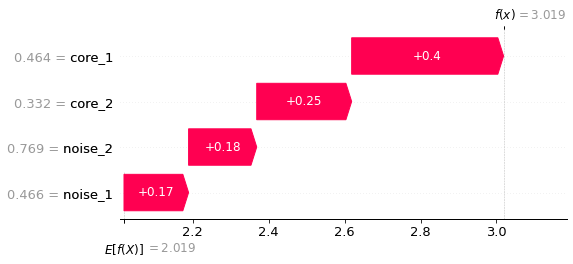

In [1157]:
# target_inst2

# test considering p_matrix generated from shapley values i row and ij row

# get the first row shapley values to fi
sh_phi_i2= get_vector_phi_i(num_fts, p_base_value, acc_no_i2)

# get the second row shapley values to fij
sh_phi_ij2= get_matrix_phi_ij(num_fts, p_base_value, acc_no_i2, acc_no_ij2)

# get the probability matrix difference between fij and fi
p_matrix_sh2= get_sh_p_matrix(num_fts, sh_phi_i2, sh_phi_ij2, mag=False, zeroDiag=True)


stationary_sh2= p_matrix_to_stationary_dist(np.abs(p_matrix_sh2), version=1)


sh_pos2, sh_neg2= split_pos_neg_p_matrix(p_matrix_sh2)


pos_stationary_sh2= p_matrix_to_stationary_dist(sh_pos2, version=1)

neg_stationary_sh2= p_matrix_to_stationary_dist(sh_neg2, version=1)


st_final= merge_pos_neg_stationary(pos_stationary_sh2, neg_stationary_sh2, stationary_sh2, merge_type="mean")

st_final= ft_ranking_regularization(st_final)

sh_test= to_sh_exp(st_final, p_base_value, np.asarray(target_inst2)[0], target_inst2.columns)

shap.plots.waterfall(sh_test)

In [1122]:
target_inst

,core_1,core_2,noise_1,noise_2
42,0.466194,0.721861,0.948764,0.04446


In [1123]:
target_inst2

,core_1,core_2,noise_1,noise_2
845,0.46423,0.331611,0.465974,0.769212


# Regressor version - REMOVE

# Mag

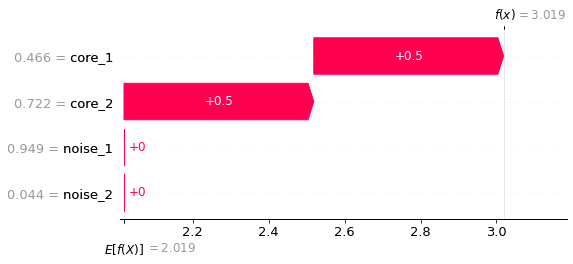

In [1250]:
# test considering p_matrix generated from no_i no_ij abs(difference)

# get the probability matrix
p_matrix_mag_reg= get_p_matrix_mag(num_fts, acc_no_i_reg, acc_no_ij_reg, zeroDiag=True)

# get the stationary distribution
stationary_mag_reg= p_matrix_to_stationary_dist(p_matrix_mag_reg)

sh_test= to_sh_exp(stationary_mag_reg, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

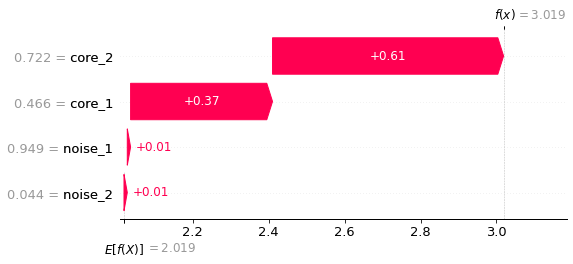

In [1253]:
# Difference and split

# get the probability matrix target_inst
p_matrix_dif_reg= get_p_matrix_dif(num_fts, acc_no_i_reg, acc_no_ij_reg, zeroDiag=True)


pos_reg, neg_reg= split_pos_neg_p_matrix(p_matrix_dif_reg)


pos_stationary_reg= p_matrix_to_stationary_dist(pos_reg)

neg_stationary_reg= p_matrix_to_stationary_dist(np.abs(neg_reg)) # note abs use


st_final= merge_pos_neg_stationary(pos_stationary_reg, neg_stationary_reg, stationary_mag_reg, 
                                     merge_type="magmean")

st_final_reg= ft_ranking_regularization(st_final)

sh_exp= to_sh_exp(st_final_reg, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_exp)

In [1230]:
stationary_mag_reg

array([5.00000e-01, 5.00000e-01, 2.77556e-17, 2.77556e-17])

In [1231]:
pos_stationary_reg

array([0.14286, 0.5    , 0.14286, 0.14286])

In [1232]:
neg_stationary_reg

array([0.375, 0.25 , 0.125, 0.125])

In [1257]:
p_matrix_dif_reg

array([[ 0.     ,  0.00469,  0.     ,  0.     ],
       [-0.10742,  0.     ,  0.     ,  0.     ],
       [ 0.     ,  0.11211,  0.     ,  0.     ],
       [ 0.     ,  0.11211,  0.     ,  0.     ]])

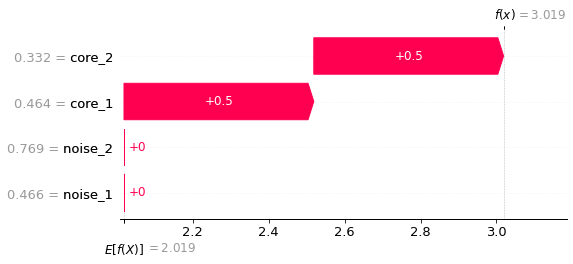

In [1164]:
# target_inst2 --- MAG

# test considering p_matrix generated from no_i no_ij abs(difference)

# get the probability matrix
p_matrix_mag_reg2= get_p_matrix_mag(num_fts, acc_no_i_reg2, acc_no_ij_reg2)

# get the stationary distribution
stationary_mag_reg2= p_matrix_to_stationary_dist(p_matrix_mag_reg2)

sh_test= to_sh_exp(stationary_mag_reg2, p_base_value, np.asarray(target_inst2)[0], target_inst2.columns)

shap.plots.waterfall(sh_test)

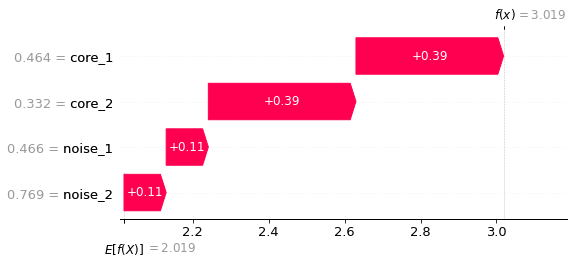

In [1256]:
# Difference and split

# get the probability matrix target_inst2
p_matrix_dif_reg2= get_p_matrix_dif(num_fts, acc_no_i_reg2, acc_no_ij_reg2)


pos_reg2, neg_reg2= split_pos_neg_p_matrix(p_matrix_dif_reg2)


pos_stationary_reg2= p_matrix_to_stationary_dist(pos_reg2)

neg_stationary_reg2= p_matrix_to_stationary_dist(np.abs(neg_reg2)) # note abs use


st_final= merge_pos_neg_stationary(pos_stationary_reg2, neg_stationary_reg2, stationary_mag_reg2, 
                                     merge_type="magmean")

st_final_reg= ft_ranking_regularization(st_final)

sh_exp= to_sh_exp(st_final_reg, p_base_value, np.asarray(target_inst2)[0], target_inst2.columns)

shap.plots.waterfall(sh_exp)

In [1210]:
stationary_mag_reg2

array([5.00000e-01, 5.00000e-01, 5.55112e-17, 5.55112e-17])

In [1209]:
pos_stationary_reg2

array([0.2, 0.2, 0.2, 0.2])

In [1208]:
neg_stationary_reg2

array([5.00000e-01, 5.00000e-01, 5.55112e-17, 5.55112e-17])

In [1258]:
p_matrix_dif_reg2

array([[ 0.     , -0.87235,  0.     ,  0.     ],
       [-0.10742,  0.     ,  0.     ,  0.     ],
       [-0.00092, -0.76584,  0.     ,  0.     ],
       [-0.00092, -0.76584,  0.     ,  0.     ]])

# Regressor version - ADD

In [2710]:
reg_no_i, reg_no_ij, reg_wt_i, reg_wt_ij= far_gen_costs_reg(xgb_regre, num_fts, replace_ft_zero, target_inst, 
                                                            verbose=True)

--- 0.47 seconds ---


In [2711]:
reg_wt_i

[0.06472042, 0.9426754, 0.06563888, 0.06563888]

In [1185]:
reg_wt_ij

[[0.06472042, 0.9426754, 0.06472042, 0.06472042],
 [0.9426754, 0.9426754, 0.9426754, 0.9426754],
 [0.06472042, 0.9426754, 0.06563888, 0.06563888],
 [0.06472042, 0.9426754, 0.06563888, 0.06563888]]

In [1204]:
# test considering p_matrix generated from no_i no_ij abs(difference)

# get the probability matrix
add_p_matrix_mag= get_p_matrix_mag(num_fts, reg_wt_i, reg_wt_ij, remove=False)

# get the stationary distribution
add_stationary_mag= p_matrix_to_stationary_dist(add_p_matrix_mag)

ft_ranking= pd.Series(add_stationary_mag, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.499851
core_1     0.143071
noise_1    0.142846
noise_2    0.142846
dtype: float64

In [1187]:
add_p_matrix_mag

array([[0.     , 0.87795, 0.     , 0.     ],
       [0.     , 0.     , 0.     , 0.     ],
       [0.00092, 0.87704, 0.     , 0.     ],
       [0.00092, 0.87704, 0.     , 0.     ]])

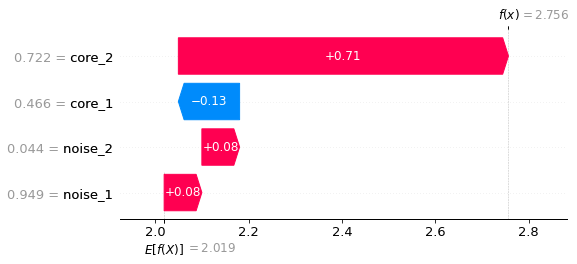

In [1205]:
# get the probability matrix
add_p_matrix_dif= get_p_matrix_dif(num_fts, reg_wt_i, reg_wt_ij, remove=False)


add_pos_reg, add_neg_reg= split_pos_neg_p_matrix(add_p_matrix_dif)


add_pos_stationary_reg= p_matrix_to_stationary_dist(add_pos_reg)

add_neg_stationary_reg= p_matrix_to_stationary_dist(np.abs(add_neg_reg)) # note abs use


st_final= merge_pos_neg_stationary(add_pos_stationary_reg, add_neg_stationary_reg, add_stationary_mag, 
                                     merge_type="mean")

st_final= ft_ranking_regularization(st_final)

sh_exp= to_sh_exp(st_final, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_exp)

In [ ]:
# get the first row shapley values to fi

f0_mean= reg_expected_value(xgb_regre, replace_ft)

add_sh_phi_i= get_vector_phi_i(num_fts, f0_mean, reg_wt_i)

# get the second row shapley values to fij
add_sh_phi_ij= get_matrix_phi_ij(num_fts, f0_mean, reg_wt_i, reg_wt_ij)

# get the probability matrix difference between fij and fi
add_p_matrix_sh= get_sh_p_matrix(num_fts, add_sh_phi_i, add_sh_phi_ij, mag=False, zeroDiag=True)

# get the stationary distribution
add_stationary_sh= p_matrix_to_stationary_dist(np.abs(add_p_matrix_sh), version=1)

ft_ranking= pd.Series(add_stationary_sh, index=train.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
add_sh_phi_i

In [ ]:
add_sh_phi_ij

In [ ]:
add_p_matrix_sh

In [ ]:
add_sh_pos, add_sh_neg= split_pos_neg_p_matrix(add_p_matrix_sh)


add_pos_stationary_sh= p_matrix_to_stationary_dist(add_sh_pos, version=1)

add_neg_stationary_sh= p_matrix_to_stationary_dist(add_sh_neg, version=1)


st_final= merge_pos_neg_stationary(add_pos_stationary_sh, add_neg_stationary_sh, add_stationary_sh, 
                                     merge_type="mean")

st_final= ft_ranking_regularization(st_final)

sh_test= to_sh_exp(st_final, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

# Test using classes "baselines"

In [ ]:
# Split the train dataset according its classes
lb_train_a= labels_train.loc[labels_train['target'] == 1]
lb_train_b= labels_train.loc[labels_train['target'] == 0]

train_a= train.loc[lb_train_a.index,:]
train_b= train.loc[lb_train_b.index,:]

In [ ]:
# determine a baseline related to each class using the mean
base_a= replace_values(train_a, train_a.columns, num_type='mean')
base_b= replace_values(train_b, train_b.columns, num_type='mean')

lb_base_a= lb_train_a.iloc[0].to_frame().T
lb_base_b= lb_train_b.iloc[0].to_frame().T

print(lb_base_a)
print("Pred base_a sample", xgb_model.predict(base_a))
print("\n")
print(lb_base_b)
print("Pred base_b sample", xgb_model.predict(base_b))
print("\n")
print(target_labl)
print("Pred sample to explain", xgb_model.predict(target_inst))

In [156]:
# get the model behavior after removing i (single ft) and ij (pair) for each baseline

a_no_i, a_no_ij= remove_and_gen_costs(xgb_model, num_fts, replace_ft_zero, base_a, lb_base_a, 
                                      use_preds= True, verbose=True)

b_no_i, b_no_ij= remove_and_gen_costs(xgb_model, num_fts, replace_ft_zero, base_b, lb_base_b, 
                                      use_preds= True, verbose=True)

--- 0.34 seconds ---
--- 0.12 seconds ---


In [157]:
# explaining the baseline - class a - target 1
# test considering p_matrix generated from shapley values i row and ij row

# get the first row shapley values to fi
a_sh_phi_i= get_vector_phi_i(num_fts, prob_mean_class, a_no_i)

# get the second row shapley values to fij
a_sh_phi_ij= get_matrix_phi_ij(num_fts, prob_mean_class, a_no_i, a_no_ij)

# get the probability matrix difference between fij and fi
a_p_matrix= get_sh_p_matrix(num_fts, a_sh_phi_i, a_sh_phi_ij, mag=True)

# get the stationary distribution
a_stationary= p_matrix_to_stationary_dist(a_p_matrix)

a_ft_ranking= pd.Series(a_stationary, index=train.columns).sort_values(ascending=False)
a_ft_ranking

core_2     0.642421
core_1     0.128022
noise_1    0.125018
noise_2    0.104538
dtype: float64

In [158]:
# explaining the baseline - class b - target 0
# test considering p_matrix generated from shapley values i row and ij row

# get the first row shapley values to fi
b_sh_phi_i= get_vector_phi_i(num_fts, prob_mean_class, b_no_i)

# get the second row shapley values to fij
b_sh_phi_ij= get_matrix_phi_ij(num_fts, prob_mean_class, b_no_i, b_no_ij)

# get the probability matrix difference between fij and fi
b_p_matrix= get_sh_p_matrix(num_fts, b_sh_phi_i, b_sh_phi_ij, mag=True)

# get the stationary distribution
b_stationary= p_matrix_to_stationary_dist(b_p_matrix)

b_ft_ranking= pd.Series(b_stationary, index=train.columns).sort_values(ascending=False)
b_ft_ranking

core_1     0.641738
core_2     0.138045
noise_2    0.124463
noise_1    0.095754
dtype: float64

In [159]:
# explaining the target instance using "neutral values" from entire dataset
# test considering p_matrix generated from shapley values i row and ij row

# get the first row shapley values to fi
sh_phi_i= get_vector_phi_i(num_fts, prob_mean_class, acc_no_i)

# get the second row shapley values to fij
sh_phi_ij= get_matrix_phi_ij(num_fts, prob_mean_class, acc_no_i, acc_no_ij)

# get the probability matrix difference between fij and fi
p_matrix= get_sh_p_matrix(num_fts, sh_phi_i, sh_phi_ij, mag=True)

# get the stationary distribution
stationary= p_matrix_to_stationary_dist(p_matrix)

ft_ranking= pd.Series(stationary, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.639042
noise_1    0.127025
noise_2    0.126198
core_1     0.107735
dtype: float64

In [160]:
from scipy.spatial import distance

# Our sample under explanation (target_inst) is predicted to class 1, such as base_a prediction

# Consider FTi = ft_rank(class(target_inst)) and 
#          base = ft_rank(class(target_inst) == class(baseline))
#
# Then ft_ranking = FTi + abs(FTi-base)/2, if FTi > base
# and  ft_ranking = FTi - abs(FTi-base)/2, if FTi < base

# both vectors must have values [0,1]

def ft_ranking_to_class_importances(target_instance, target_stationary, base_instance, base_stationary, 
                                    w_dist:bool=False, reg_negs:bool=False):
    
    final_stationary= target_stationary.copy()
    
    dist= distance.euclidean(np.asarray(target_instance), np.asarray(base_instance))

    for i in range(len(stationary)):
        targ= target_stationary[i]
        base= base_stationary[i]

        if (targ> base):
            if (w_dist==False):
                final_stationary[i]= targ - (np.abs(targ-base)/2)
            else:
                final_stationary[i]= targ - dist*(np.abs(targ-base)/2)
        else:
            if (w_dist==False):
                final_stationary[i]= targ + (np.abs(targ-base)/2)
            else:
                final_stationary[i]= targ + dist*(np.abs(targ-base)/2)
            
    if (reg_negs==True):
        final_stationary= ft_ranking_regularization(final_stationary)
        
    return final_stationary

In [161]:
# We have class(target_inst)==1, class(base_a)==1 and class(base_b)==0

final_stationary= ft_ranking_to_class_importances(target_inst, stationary, base_a, a_stationary)

final_ft_ranking= pd.Series(final_stationary, index=train.columns).sort_values(ascending=False)
final_ft_ranking

core_2     0.640732
noise_1    0.126022
core_1     0.117879
noise_2    0.115368
dtype: float64

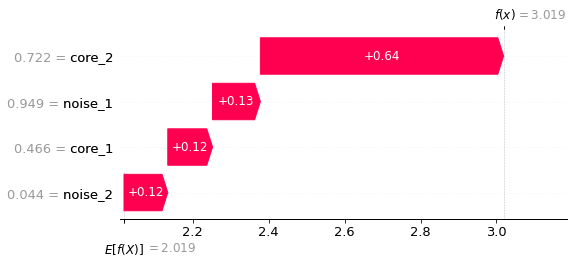

In [162]:
sh_test= to_sh_exp(final_stationary, exp_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

In [163]:
reg_final_ft_ranking= pd.Series(ft_ranking_regularization(final_stationary), 
                                index=train.columns).sort_values(ascending=False)
reg_final_ft_ranking

core_2     0.640732
noise_1    0.126022
core_1     0.117879
noise_2    0.115368
dtype: float64

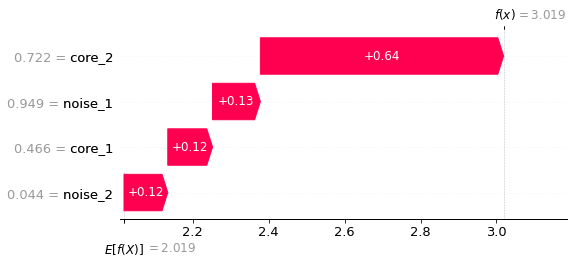

In [164]:
sh_test= to_sh_exp(ft_ranking_regularization(final_stationary), exp_value, np.asarray(target_inst)[0], 
                   target_inst.columns)

shap.plots.waterfall(sh_test)

# Using divergence

In [165]:
# baseline - class a - target 1
# test considering p_matrix generated from no_i no_ij divergence

# get the probability matrix
a_p_matrix= get_p_matrix_div(num_fts, a_no_i, a_no_ij)

# get the stationary distribution
a_stationary= p_matrix_to_stationary_dist(a_p_matrix)

a_ft_ranking= pd.Series(a_stationary, index=train.columns).sort_values(ascending=False)
a_ft_ranking

core_2     0.499979
noise_2    0.499418
noise_1    0.000429
core_1     0.000174
dtype: float64

In [166]:
# baseline - class b - target 0
# test considering p_matrix generated from no_i no_ij divergence

# get the probability matrix
b_p_matrix= get_p_matrix_div(num_fts, b_no_i, b_no_ij)

# get the stationary distribution
b_stationary= p_matrix_to_stationary_dist(b_p_matrix)

b_ft_ranking= pd.Series(b_stationary, index=train.columns).sort_values(ascending=False)
b_ft_ranking

core_1     0.334826
core_2     0.329540
noise_2    0.329506
noise_1    0.006128
dtype: float64

In [167]:
# explaining the target instance using "neutral values" from entire dataset
# test considering p_matrix generated from no_i no_ij divergence

# get the probability matrix
p_matrix= get_p_matrix_div(num_fts, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary= p_matrix_to_stationary_dist(p_matrix)

ft_ranking= pd.Series(stationary, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.499981
core_1     0.451667
noise_1    0.047005
noise_2    0.001347
dtype: float64

In [168]:
# We have class(target_inst)==1, class(base_a)==1 and class(base_b)==0

final_stationary= ft_ranking_to_class_importances(target_inst, stationary, base_a, a_stationary)

final_ft_ranking= pd.Series(final_stationary, index=train.columns).sort_values(ascending=False)
final_ft_ranking

core_2     0.499980
noise_2    0.250382
core_1     0.225920
noise_1    0.023717
dtype: float64

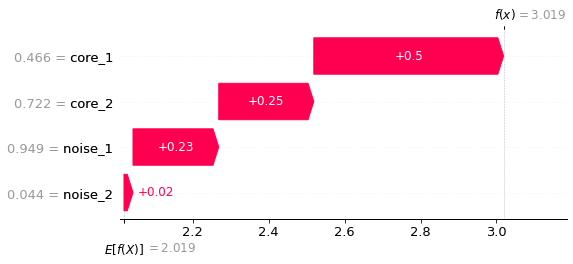

In [169]:
sh_test= to_sh_exp(final_ft_ranking, exp_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

In [179]:
# get the model behavior after removing process of i (single ft) and ij (pair)

num_fts= len(x_syn.columns)

acc_no_i, acc_no_ij= remove_and_gen_costs(xgb_model, num_fts, replace_ft, target_inst, target_labl, 
                                          use_preds= True, verbose=True)

--- 0.3 seconds ---


In [180]:
# test considering p_matrix generated from shapley values i row and ij row

# get the first row shapley values to fi
sh_phi_i= get_vector_phi_i(num_fts, p_base_value, acc_no_i)

# get the second row shapley values to fij
sh_phi_ij= get_matrix_phi_ij(num_fts, p_base_value, acc_no_i, acc_no_ij)

# get the probability matrix difference between fij and fi
p_matrix= get_sh_p_matrix(num_fts, sh_phi_i, sh_phi_ij, mag=True)

# get the stationary distribution
stationary= p_matrix_to_stationary_dist(p_matrix)

ft_ranking= pd.Series(stationary, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.659479
core_1     0.126751
noise_2    0.107020
noise_1    0.106750
dtype: float64

In [181]:
# We have class(target_inst)==1, class(base_a)==1 and class(base_b)==0

final_stationary= ft_ranking_to_class_importances(target_inst, stationary, base_b, b_stationary)

final_ft_ranking= pd.Series(final_stationary, index=train.columns).sort_values(ascending=False)
final_ft_ranking

core_2     0.494510
core_1     0.230788
noise_2    0.218263
noise_1    0.056439
dtype: float64

In [182]:
sh_phi_i

array([ 2.65241e-06, -2.24887e-03,  0.00000e+00,  5.96046e-08])

In [183]:
acc_no_i

[0.5049132108688354,
 0.49590712785720825,
 0.5049026012420654,
 0.5049028396606445]

In [184]:
sh_phi_ij

array([[-8.76918e-04, -8.84031e-04,  3.53654e-06,  3.57628e-06],
       [-3.13555e-03, -9.13433e-03, -2.99849e-03, -3.00029e-03],
       [ 8.84136e-07, -7.49623e-04, -7.48719e-04,  1.98682e-08],
       [ 9.83477e-07, -7.51361e-04,  7.94729e-08, -7.50298e-04]])

In [185]:
print(acc_no_ij)

[[0.5049132108688354, 0.4950900673866272, 0.5049132108688354, 0.5049135684967041], [0.4950900673866272, 0.49590712785720825, 0.49590712785720825, 0.49589645862579346], [0.5049132108688354, 0.49590712785720825, 0.5049026012420654, 0.5049028396606445], [0.5049135684967041, 0.49589645862579346, 0.5049028396606445, 0.5049028396606445]]


In [186]:
p_matrix_dif= get_sh_p_matrix(num_fts, sh_phi_i, sh_phi_ij, mag=False)
p_matrix_dif

array([[ 2.65241e-06, -8.86684e-04,  8.84136e-07,  9.23872e-07],
       [-8.86684e-04, -2.24887e-03, -7.49623e-04, -7.51421e-04],
       [ 8.84136e-07, -7.49623e-04,  0.00000e+00,  1.98682e-08],
       [ 9.23872e-07, -7.51421e-04,  1.98682e-08,  5.96046e-08]])

In [187]:
p_matrix

array([[2.65241e-06, 8.86684e-04, 8.84136e-07, 9.23872e-07],
       [8.86684e-04, 2.24887e-03, 7.49623e-04, 7.51421e-04],
       [8.84136e-07, 7.49623e-04, 0.00000e+00, 1.98682e-08],
       [9.23872e-07, 7.51421e-04, 1.98682e-08, 5.96046e-08]])

In [188]:
signal_lin_p_matrix= np.zeros(num_fts)

for i in range(num_fts):
    signal_lin_p_matrix[i]= np.prod(p_matrix_dif[i])
    
signal_ft= np.zeros(num_fts)
    
for i in range(num_fts):
    signal_ft[i]= signal_lin_p_matrix[i]
    
    for j in range(num_fts):
        if (i!=j):
            signal_ft[i]= signal_ft[i]*p_matrix_dif[j][i]
    
signal_ft

array([ 1.39136e-36, -5.60988e-22,  0.00000e+00,  1.13393e-41])

# New attempt - considering top and bottom 1/n elements

In [206]:
def sh_values_top_bottom(model, n_fts, exp_sample, exp_label, replace_ft, verbose=False):
    start= time.time()
    
    f_0= model.predict(replace_ft)[0]
    
    f_x= model.predict(exp_sample)[0]
    
    f_i, f_ij= add_and_gen_costs_reg(model, n_fts, replace_ft, exp_sample, verbose)
    
    f_no_i= []
    
    for i in range(n_fts):  # add and predict process to get gains/losses
        
        # replace_ft contains "neutral" values to each feature, now we add all the features from x_to_exp
        # except the i-th value from replace_ft one by one the assess gain/loses
        x_to_exp_no_i= exp_sample.copy()
        x_to_exp_no_i.loc[:,x_to_exp_no_i.columns[i]]= replace_ft.iloc[0,i]
        
        f_no_i.append(model.predict(x_to_exp_no_i)[0])
        
    phi_i= []
    
    for i in range(n_fts):
        phi_i.append((1/ n_fts)*(f_i[i]- f_0))
        
        for j in range(n_fts):
            top= 0
            btm= 0
            
            if (i!=j):
                top= (1/(n_fts*(n_fts-1)))*(2*f_ij[i][j]- f_i[i]- f_i[j])   
            elif (i==j):
                btm= (1/ n_fts)*(f_x- f_no_i[i])
                
            phi_i[i]= phi_i[i] + top + btm
            
            
    phi_ij= (1/ n_fts)*(f_ij- f_0)
    
    for i in range(n_fts):
        for j in range(n_fts):
            
            if (i!= j):
                x_to_exp_no_ij= exp_sample.copy()
                x_to_exp_no_ij.loc[:,x_to_exp_no_ij.columns[i]]= replace_ft.iloc[0,i]
                x_to_exp_no_ij.loc[:,x_to_exp_no_ij.columns[j]]= replace_ft.iloc[0,j]

                f_no_ij= model.predict(x_to_exp_no_ij)[0]
                
                phi_ij[i][j]= phi_ij[i][j] + (1/ n_fts)*(f_x - f_no_ij)
            else:
                phi_ij[i][i]= 0
                
    if (verbose==True):
        print("--- %s seconds ---" % np.round((end- start), 2))
        
    return phi_i, phi_ij

In [207]:
new_phi_i, new_phi_ij= sh_values_top_bottom(reg, num_fts, target_inst, target_labl, replace_ft_zero)
new_phi_ij

array([[ 0.     , -0.00046, -0.00046, -0.00046],
       [-0.00046,  0.     ,  0.     ,  0.     ],
       [-0.00046,  0.     ,  0.     ,  0.     ],
       [-0.00046,  0.     ,  0.     ,  0.     ]], dtype=float32)

In [208]:
# get the probability matrix difference between fij and fi
p_matrix= get_sh_p_matrix(num_fts, new_phi_i, new_phi_ij, mag=True)

# get the stationary distribution
stationary= p_matrix_to_stationary_dist(p_matrix,version=1)

ft_ranking= pd.Series(stationary, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.555556
noise_1    0.148148
core_2     0.148148
noise_2    0.148148
dtype: float64

In [209]:
p_matrix

array([[6.88842e-04, 2.29614e-04, 2.29614e-04, 2.29614e-04],
       [3.82690e-04, 7.65380e-05, 7.65380e-05, 7.65380e-05],
       [3.82690e-04, 7.65380e-05, 7.65380e-05, 7.65380e-05],
       [3.82690e-04, 7.65380e-05, 7.65380e-05, 7.65380e-05]])

In [210]:
new_phi_i

[-0.0006888415664434433,
 -7.653795182704926e-05,
 -7.653795182704926e-05,
 -7.653795182704926e-05]

# Tests using LIME

In [116]:
import lime
import lime.lime_tabular

explainer= lime.lime_tabular.LimeTabularExplainer(np.asarray(train), feature_names=np.asarray(train.columns), 
                                                  class_names= np.asarray([0,1]), verbose=False, 
                                                  mode='classification', discretize_continuous=False)

In [117]:
exp= explainer.explain_instance(np.asarray(target_inst)[0], xgb_model.predict_proba, num_features=4, 
                                top_labels=1)

exp.show_in_notebook(show_table=True, show_all=True)

In [117]:
exp.local_exp[1]

[(1, 0.0028097297816073764),
 (0, -0.0026850547906389476),
 (2, -4.47176302082646e-05),
 (3, -2.426737817348242e-05)]

In [118]:
lime_exp_in_data_order(exp, train.shape[1])

array([-2.68505e-03,  2.80973e-03, -4.47176e-05, -2.42674e-05])

In [191]:
print('Element id: %d' % target_pos)
print('Probability(0 class) =', xgb_model.predict_proba(target_inst)[0,0])
print('True class: %s' % int(np.asarray(target_labl)[0]))

Element id: 9
Probability(0 class) = 0.5049026
True class: 0


# Feature Attribution using PageRank

# PageRank-based methods

In [ ]:
def run_lib_pr(graph_matrix, ft_names, iteration= 100, damping_factor= 0.85, tolerance= 1.0e-6):
    
    num_fts= graph_matrix.shape[0]
    
    D= nx.DiGraph()

    for i in range(num_fts):
        for j in range(num_fts):
            if (i!= j):
                D.add_weighted_edges_from([(ft_names[i],ft_names[j],graph_matrix[i,j])])
    
                
    pRank= pd.Series(nx.pagerank(D, max_iter=iteration, alpha=damping_factor, tol=tolerance))

    return pRank.sort_values(ascending=False)

In [ ]:
# using my PR to compare results
def run_my_pr(graph_matrix, ft_names, iteration= 100, damping_factor= 0.95, tolerance= 1.0e-6):
    
    file_path= 'datasets/FAR_data.txt'
    
    num_fts= graph_matrix.shape[0]

    f= open(file_path, 'w')

    for i in range(num_fts):
        for j in range(num_fts):
            line= (str(int(i)) + ',' + str(int(j)) + ',' + str(graph_matrix[i,j]) + '\n')
            f.write(line)

    f.close()

    graph= gpr.init_graph(file_path)

    myPRank= pd.Series(pr.run_PageRank(graph, iteration=iteration, damping_factor=damping_factor, 
                                       tolerance=tolerance))
    myPRank= myPRank.sort_values(ascending=False)
    
    ids_names= ft_names[(myPRank.index).astype(int)]

    myPRank.index= ids_names

    return myPRank

# OLD versions --- Tests using the Titanic dataset ---

# Data loading and preprocessing

In [ ]:
#!kaggle competitions download -c titanic

In [ ]:
ds= zf.ZipFile('datasets/titanic.zip')

train_data= pd.read_csv(ds.open('train.csv'))
test_data= pd.read_csv(ds.open('test.csv'))

train_data.shape, test_data.shape

In [ ]:
train_data.head()

In [ ]:
test_data.head()

In [ ]:
X_all= pd.concat([train_data[['PassengerId','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']],
                   test_data[['PassengerId','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]]).set_index('PassengerId')

y_train= train_data[['PassengerId','Survived']].set_index('PassengerId')['Survived']

X_all

In [ ]:
numeric_columns= ['Age','SibSp','Parch','Fare']
categor_columns= list(filter(lambda x:x not in numeric_columns,X_all.columns))

X_train= X_all.iloc[:len(train_data),:].copy()
X_test= X_all.iloc[len(train_data):].copy()

In [ ]:
# in this case we'll only use X_train df because X_test is not labeled

In [ ]:
X_train= pre_proc_fillna_num_fts(X_train,numeric_columns,num_type='median')

X_train= pre_proc_fillna_cat_fts(X_train,categor_columns,cat_type='mode')

X_train

In [ ]:
# one-hot encoding the qualitative features
X_train_ohe= pd.get_dummies(X_train,columns=categor_columns)

X_train_ohe.head()

In [ ]:
y_train.head()

In [ ]:
# normalize the numeric columns of dataframe with each value between 0 and 1
X_train= normalize_selected(X_train, numeric_columns)
X_train_ohe= normalize_selected(X_train_ohe, numeric_columns)

# ML model setup

In [ ]:
train, test, labels_train, labels_test= train_test_split(X_train_ohe,y_train,train_size=0.80,random_state=1234)
rf= sklearn.ensemble.RandomForestClassifier(n_estimators=500,n_jobs=2)

#train, test, labels_train, labels_test= train_test_split(X_train_ohe,y_train,train_size=0.80,random_state=1234)
#xgb_model= xgb.XGBRFClassifier(n_estimators=500,eval_metric='logloss',use_label_encoder=False)

#train, test, labels_train, labels_test= train_test_split(X_train,y_train,train_size=0.80,random_state=1234)
#cat_fts= [train.columns.to_list().index(col) for col in categor_columns]
#ctb_model= CatBoostClassifier(cat_features=cat_fts,silent=True)

# --- Run global modeling (no retraining) ---

In [ ]:
repeat_train= 1

num_fts= len(train.columns)

In [ ]:
# train the ML model and get the accuracy using the entire feature set
acc_all_fts= train_model_get_acc_mean(rf, train, test, labels_train, labels_test, repeat_train)

# rf is the model trained

acc_all_fts

In [ ]:
# values to "remove" (entire dataset)
replace_ft= replace_values(X_train_ohe, numeric_columns, num_type='mean', cat_type='median')

replace_ft

In [ ]:
# calculates "transition" costs removing columns from the feature set using a trained model

acc_no_i, acc_no_ij= remove_and_return_costs(rf, replace_ft, test, labels_test, True)

In [ ]:
#print(acc_no_i)
print(np.around(acc_no_i, decimals=3))
print("-----------------------------")
#print(acc_no_ij)
print(np.around(acc_no_ij, decimals=3))

In [ ]:
# get the probability matrix
p_matrix1= get_p_matrix_mag(num_fts, acc_no_i, acc_no_ij)
p_matrix2= get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

#print(p_matrix1)
print(np.around(p_matrix1, decimals=3))
print("-----------------------------")
#print(p_matrix2)
print(np.around(p_matrix2, decimals=3))
print("-----------------------------")
#print(p_matrix3)
print(np.around(p_matrix3, decimals=3))
print("-----------------------------")
#print(p_matrix4)
print(np.around(p_matrix4, decimals=3))

In [ ]:
# get the stationary distribution
stationary_d1= p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= p_matrix_to_stationary_dist(p_matrix4)

print(stationary_d1)
print("-----------------------------")
print(stationary_d2)
print("-----------------------------")
print(stationary_d3)
print("-----------------------------")
print(stationary_d4)

In [ ]:
rp_list= {'Sex_male':'Sex','Sex_female':'Sex','Pclass_1':'Pclass','Pclass_2':'Pclass','Pclass_3':'Pclass',
          'Embarked_S':'Embarked','Embarked_Q':'Embarked','Embarked_C':'Embarked'}

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d1, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d2, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d2,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d3, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d4, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

# --- Run local modeling (k-NN version, no retraining) ---

In [ ]:
# the instance to be explained (from train dataset)
target_index= 1

target_inst= train.loc[train.index== target_index]
target_labl= labels_train.loc[labels_train.index== target_index]

In [ ]:
# calculates "transition" costs removing columns from a target instance using a trained model
# target instance is supported by neighb_size percent nearest neighbors of test dataset

acc_no_i, acc_no_ij= knn_remove_and_return_costs(rf, replace_ft, test, labels_test, target_inst, target_labl,
                                                 neighb_size= 0.5, verbose=True)

In [ ]:
print(acc_all_fts)
print("-----------------------------")
#print(acc_no_i)
print(np.around(acc_no_i, decimals=3))
print("-----------------------------")
#print(acc_no_ij)
print(np.around(acc_no_ij, decimals=3))

In [ ]:
# get the probability matrix
p_matrix1= get_p_matrix_mag(num_fts, acc_no_i, acc_no_ij)
p_matrix2= get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

#print(p_matrix1)
print(np.around(p_matrix1, decimals=3))
print("-----------------------------")
#print(p_matrix2)
print(np.around(p_matrix2, decimals=3))
print("-----------------------------")
#print(p_matrix3)
print(np.around(p_matrix3, decimals=3))
print("-----------------------------")
#print(p_matrix4)
print(np.around(p_matrix4, decimals=3))

In [ ]:
# get the stationary distribution
stationary_d1= p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= p_matrix_to_stationary_dist(p_matrix4)

print(stationary_d1)
print("-----------------------------")
print(stationary_d2)
print("-----------------------------")
print(stationary_d3)
print("-----------------------------")
print(stationary_d4)

In [ ]:
rp_list= {'Sex_male':'Sex','Sex_female':'Sex','Pclass_1':'Pclass','Pclass_2':'Pclass','Pclass_3':'Pclass',
          'Embarked_S':'Embarked','Embarked_Q':'Embarked','Embarked_C':'Embarked'}

In [ ]:
# TARGET INSTANCE TO EXPLAIN ITS FEATURES

X_all.loc[X_all.index== target_index]

In [ ]:
target_label

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d1, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d2, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d2,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d3, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d4, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

# --- Run PageRank approach (k-NN local version, no retraining) ---

In [ ]:
print(acc_all_fts)
print("-----------------------------")
#print(acc_no_i)
print(np.around(acc_no_i, decimals=3))
print("-----------------------------")
#print(acc_no_ij)
print(np.around(acc_no_ij, decimals=3))

In [ ]:
# get the probability matrix
p_matrix1= get_p_matrix_mag(num_fts, acc_no_i, acc_no_ij)
p_matrix2= get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# finding the stationary distribution
st_matrix1= p_matrix_to_row_stochastic_matrix(p_matrix1)
st_matrix2= p_matrix_to_row_stochastic_matrix(p_matrix2)
st_matrix3= p_matrix_to_row_stochastic_matrix(p_matrix3)
st_matrix4= p_matrix_to_row_stochastic_matrix(p_matrix4)

In [ ]:
run_lib_pr(st_matrix1, X_train_ohe.columns)

In [ ]:
run_lib_pr(st_matrix2, X_train_ohe.columns)

In [ ]:
run_lib_pr(st_matrix3, X_train_ohe.columns)

In [ ]:
run_lib_pr(st_matrix4, X_train_ohe.columns)

In [ ]:
run_my_pr(st_matrix1, X_train_ohe.columns)

In [ ]:
run_my_pr(st_matrix2, X_train_ohe.columns)

In [ ]:
run_my_pr(st_matrix3, X_train_ohe.columns)

In [ ]:
run_my_pr(st_matrix4, X_train_ohe.columns)

# --- Run local modeling (k-Fold version, no retraining) ---

In [ ]:
# calculates "transition" costs removing columns from a target instance using a trained model
# target instance is supported by neighb_size percent nearest neighbors of test dataset applied in a kfolding way

acc_no_i, acc_no_ij= knnfold_remove_and_return_costs(rf, replace_ft, test, labels_test, 
                                                     target_inst, target_labl, neighb_size= 0.5, 
                                                     k_folds=10, verbose=True)

In [ ]:
print(acc_all_fts)
print("-----------------------------")
#print(acc_no_i)
print(np.around(acc_no_i, decimals=3))
print("-----------------------------")
#print(acc_no_ij)
print(np.around(acc_no_ij, decimals=3))

In [ ]:
# get the probability matrix
p_matrix1= get_p_matrix_mag(num_fts, acc_no_i, acc_no_ij)
p_matrix2= get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

#print(p_matrix1)
print(np.around(p_matrix1, decimals=3))
print("-----------------------------")
#print(p_matrix2)
print(np.around(p_matrix2, decimals=3))
print("-----------------------------")
#print(p_matrix3)
print(np.around(p_matrix3, decimals=3))
print("-----------------------------")
#print(p_matrix4)
print(np.around(p_matrix4, decimals=3))

In [ ]:
# get the stationary distribution
stationary_d1= p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= p_matrix_to_stationary_dist(p_matrix4)

print(stationary_d1)
print("-----------------------------")
print(stationary_d2)
print("-----------------------------")
print(stationary_d3)
print("-----------------------------")
print(stationary_d4)

In [ ]:
rp_list= {'Sex_male':'Sex','Sex_female':'Sex','Pclass_1':'Pclass','Pclass_2':'Pclass','Pclass_3':'Pclass',
          'Embarked_S':'Embarked','Embarked_Q':'Embarked','Embarked_C':'Embarked'}

In [ ]:
# TARGET INSTANCE TO EXPLAIN ITS FEATURES

X_all.loc[X_all.index== target_index]

In [ ]:
target_label

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d1, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d2, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d2,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d3, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d4, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

# --- Global version with retraining ---

In [ ]:
repeat_train= 5

acc_all_fts= train_model_get_acc_mean(rf, train, test, labels_train, labels_test, repeat_train)

acc_no_i, acc_no_ij= remove_and_retrain(rf, replace_ft, train, test, labels_train, labels_test,
                                        repeat_train, verbose=True)

In [ ]:
# get the probability matrix
p_matrix1= get_p_matrix_mag(num_fts, acc_no_i, acc_no_ij)
p_matrix2= get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= p_matrix_to_stationary_dist(p_matrix4)

In [ ]:
rp_list= {'Sex_male':'Sex','Sex_female':'Sex','Pclass_1':'Pclass','Pclass_2':'Pclass','Pclass_3':'Pclass',
          'Embarked_S':'Embarked','Embarked_Q':'Embarked','Embarked_C':'Embarked'}

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d1, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d2, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d2,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d3, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d4, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

# Misc

In [ ]:
eigval, eigvec= eigs(st_matrix3.T, k=1, which='LM')
eigval

In [ ]:
f= open('datasets/FAR_data.txt', 'w')

for i in range(num_fts):
    for j in range(num_fts):
        line= (str(i) + ',' + str(j) + ',' + str(p_matrix1[i][j]) + '\n')
        f.write(line)
        
f.close()